# BERT/RoBERTa Pretraining 수평·수직 교차 아블레이션 스터디

본 프로젝트는 한국어 위키 코퍼스를 활용하여 BERT 및 RoBERTa 모델의 사전 학습(Pretrain)을 진행하고, 전처리·태스크 설계 및 모델 경량화 구조가 언어 모델링 성능에 미치는 영향을 규명하기 위한 교차 아블레이션 연구(Matrix Ablation Study)이다.

---

## 1. 실험 설계 매트릭스
- **수평 축 (BERT vs RoBERTa vs AL-RoBERTa 비교)**: 유사 파라미터 규모(1M~1.4M) 제약 하에서 BERT 표준형(Model 0) 대비 RoBERTa 설계(Model 5)의 전처리·태스크 효율을 분석하고, 동일한 RoBERTa 레시피를 공유하는 상황에서 가중치 공유 및 임베딩 분리 구조가 적용된 AL-RoBERTa(Model 4)의 용량 대비 성능 방어력을 비교 검증한다.

- **수직 축 (모델 경량화 비교)**: 기준 모델(Model 1)에서 출발하여 임베딩 분리(Factorized Embedding) 및 가중치 공유(Weight Sharing) 기법을 단계적으로 누적 적용하며 성능 변화를 분석한다.

| 모델 번호 | 모델 이름 | 파라미터 수 | 아키텍처 스펙 ($H, L, E$) | 가중치 공유 여부 | 전처리 및 태스크 레시피 | 실험 군에서의 핵심 역할 |
| :---: | :--- | :---: | :---: | :---: | :--- | :--- |
| **Model 0** | TinyBERT | ~1.41M | $H=128, L=2, E=128$ | False | BERT (MLM + NSP, 패딩) - 정적 마스크 | 학습 레시피 비교 대조군 |
| **Model 5** | Tiny RoBERTa | ~1.41M | $H=128, L=2, E=128$ | False | RoBERTa (Only MLM, 패킹) - 동적 마스크 | 수평 축: 전처리 및 학습 태스크 영향 검증 |
| **Model 4** | AL-RoBERTa (교차) | ~1.05M | $H=256, L=6, E=32$ | True | RoBERTa (Only MLM, 패킹) - 동적 마스크 | 수평·수직의 교차점: 복합 경량화 기법 성능 검증 |
| **Model 3** | 가중치 공유형 | ~2.90M | $H=256, L=6, E=256$ | True | RoBERTa (Only MLM, 패킹) - 동적 마스크 | 수직 축: 가중치 공유의 단독 영향 검증 |
| **Model 2** | 임베딩 분리형 | ~5.03M | $H=256, L=6, E=32$ | False | RoBERTa (Only MLM, 패킹) - 동적 마스크 | 수직 축: 임베딩 분리의 단독 영향 검증 |
| **Model 1** | RoBERTa 스케일 다운 | ~6.78M | $H=256, L=6, E=256$ | False | RoBERTa (Only MLM, 패킹) - 동적 마스크 | 수직 축 아블레이션의 기준 대조군 |


## Chapter 1. 환경 설정 및 시드 고정

In [19]:
import os
import re
import math
import random
import copy
import json
import uuid
import gc
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sentencepiece as spm
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchinfo import summary

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.enabled = False

seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [20]:
# ==============================================================================
# [통제 변수] COMMON_CONFIG: 모든 실험군 모델에 공통·엄격 적용되는 글로벌 하이퍼파라미터
# ==============================================================================

COMMON_CONFIG = {
    # 1. 단어장 및 입력 데이터 스펙 (Data Dimension Control)
    "vocab_size": 8000,                  
    "max_position_embeddings": 256,       # [최대 문장 길이] n_seq. 모델이 한 번에 연산할 수 있는 최대 토큰 시퀀스 길이.
    "type_vocab_size": 2,                # [세그먼트 타입 수] BERT의 NSP(다음 문장 예측) 태스크를 위한 문장 A / 문장 B 식별 임베딩 개수.
    "pad_token_id": 0,                   # [패딩 토큰 ID] 빈 공간을 채우는 [PAD] 토큰의 인덱스 번호. (해당 위치는 어텐션 마스크로 연산 제외)

    # 2. 수리적 정규화 및 수렴 안정화 장치 (Numerical Stability)
    "layer_norm_eps": 1e-12,             # [레이어 노름 엡실론] Layer Normalization 연산 중 분모가 0이 되는 분모 제로(Division by Zero) 현상을 막기 위한 미세 상수.
    "hidden_dropout_prob": 0.1,          # [은닉층 드롭아웃 비중] FFN 및 내부 밀집층(Dense Layer)에서 과적합을 방지하기 위해 무작위로 누락시킬 뉴런의 비율 (10%).
    "attention_probs_dropout_prob": 0.1, # [어텐션 드롭아웃 비중] 멀티 헤드 어텐션 스코어 매트릭스 내부에서 특정 관계에 과적합되지 않도록 규제하는 비율 (10%).
    "initializer_range": 0.02,           # [가중치 초기화 표준편차] 모델 빌드 시 각 레이어의 파라미터(Weight)를 평균 0, 표준편차 0.02의 정규분포로 미세하게 초기화하여 그라디언트 폭발/소실 방지.

    # 3. 훈련 스케줄러 및 엔지니어링 최적화 (Training Strategy)
    "total_epochs": 10,                  # [총 학습 횟수] 전체 100만 문장 데이터를 완전히 완독하는 총 반복 횟수. (코사인 어닐링 스케줄러의 총 주기 기준점)
    "batch_size": 64,                    # [배치 크기] GPU 연산 한 번에 모델이 동시에 처리하는 문장의 개수. (수렴의 안정성과 그라디언트 노이즈 결정)
    "learning_rate_warmup": 0.1,         # [웜업 스케줄링 비중] 전체 학습 스텝 중 초기 10%(1에폭 분량) 동안 최저 LR부터 서서히 올려 가중치 공유 모델(ALBERT 기믹)의 그라디언트 발산 및 NaN 에러를 원천 봉쇄.
    "optimizer": "AdamW"                 # [최적화 알고리즘] 가중치 감쇠(Weight Decay)를 수학적으로 올바르게 분리 적용하여 모델 경량화 시 파라미터가 튀지 않도록 제어하는 트랜스포머 표준 옵티마이저.
}
N_SEQ = COMMON_CONFIG["max_position_embeddings"]
BATCH_SIZE = COMMON_CONFIG["batch_size"]
EPOCHS = COMMON_CONFIG["total_epochs"]

# 전체 데이터셋을 사용하기 위해 None으로 설정 (소규모 디버깅 테스트 시 정수 입력 가능)
COUNT = None
print(f"Dataset loading limit: {COUNT if COUNT is not None else 'All Instances'}")


Dataset loading limit: All Instances


## Chapter 2. 토크나이저 준비

In [21]:
import os
import sentencepiece as spm

model_dir = "models"
model_prefix = os.path.join(model_dir, "ko_8000")
model_path = model_prefix + ".model"

# 1. 토크나이저 모델 존재 여부 확인 및 조건부 학습
if os.path.exists(model_path):
    print(f"기존 토크나이저 모델 발견: '{model_path}'를 로드합니다.")
else:
    print(f"토크나이저 모델이 존재하지 않습니다. 새로 학습을 시작합니다.")
    os.makedirs(model_dir, exist_ok=True)
    
    # SentencePiece 학습 파라미터 구성
    spm.SentencePieceTrainer.train(
        input="data/kowiki.txt",              # 입력 텍스트 코퍼스 경로
        model_prefix=model_prefix,            # 저장될 파일명 접두사
        vocab_size=8000,                      # 단어장 크기 설정
        model_type="bpe",                     # BPE(Byte Pair Encoding) 기반
        character_coverage=0.9995,            # 한국어 권장 커버리지
        user_defined_symbols=[
            "[PAD]", "[UNK]", "[BOS]", "[EOS]", "[SEP]", "[CLS]", "[MASK]"
        ]                                     # 인덱스 0~6에 고정할 특수 토큰 정의
    )
    print("새로운 SentencePiece 모델 학습 및 저장이 완료되었습니다.")

# 2. 토크나이저 로드
vocab = spm.SentencePieceProcessor()
vocab.load(model_path)

# ==========================================
# [수정] 실제 토크나이저 단어장 크기(8007)로 설정 갱신
# ==========================================
COMMON_CONFIG["vocab_size"] = len(vocab)

print("\nVocabulary Size:", len(vocab))
print("Special token IDs:")
for id in range(7):
    print(f"ID {id}: {vocab.id_to_piece(id)}")

# 3. 특수 토큰(0~6)을 제외한 무작위 치환용 vocab_list 구축
vocab_list = []
for id in range(7, len(vocab)):
    if not vocab.is_unknown(id):
        vocab_list.append(vocab.id_to_piece(id))
print("\nRandom replacement vocab size:", len(vocab_list))



기존 토크나이저 모델 발견: 'models\ko_8000.model'를 로드합니다.

Vocabulary Size: 8007
Special token IDs:
ID 0: [PAD]
ID 1: [UNK]
ID 2: [BOS]
ID 3: [EOS]
ID 4: [SEP]
ID 5: [CLS]
ID 6: [MASK]

Random replacement vocab size: 8000


In [22]:
# 토크나이저 인코딩 검증
sample_text = "이순신은 조선 중기의 무신이었다."
pieces = vocab.encode_as_pieces(sample_text)
ids = vocab.encode_as_ids(sample_text)
print("Sample Pieces:", pieces)
print("Sample IDs:", ids)

Sample Pieces: ['▁이', '순', '신', '은', '▁조선', '▁중', '기의', '▁무', '신', '이었다', '.']
Sample IDs: [8, 3946, 3695, 3613, 346, 35, 569, 107, 3695, 437, 3599]


## Chapter 3. 프리트레이닝 데이터셋 구축 및 물리적 격리

### 1. 데이터셋 분할 및 격리 정책 (Train / Validation Split)
본 실험에서는 사전 학습 모델의 일반화 성능을 왜곡 없이 정밀 측정하고 평가의 신뢰성을 확보하기 위해 학습 데이터와 검증 데이터를 원본 텍스트 레벨에서 물리적으로 격리하는 정책을 수립하였다.
*   **분할 비율 및 수량**: 원본 위키백과 코퍼스(`kowiki.txt`)를 단락(Paragraph) 단위로 로드한 뒤, 학습 데이터셋(Train) 100,000 단락과 검증 데이터셋(Val) 5,000 단락으로 무작위 분리하였다.
*   **평가 동질성 보장**: 텍스트 분할 단계에서 원본 텍스트를 트레인과 평가용으로 나눠서 따로 txt파일러 저장함으로써, 후속 단계에서 BERT와 RoBERTa용 데이터셋을 개별 가공하더라도 검증에 투입되는 원본 소스 문서 풀이 100% 동일하게 일치하도록 통제하였다.
    *   **Train 임시 텍스트 파일(data/kowiki_train.txt)**: 총 100,000 단락 (실질 토큰 수: 31,979,516 개)
    *   **Val 임시 텍스트 파일(data/kowiki_val.txt)**: 총 5,000 단락 (실질 토큰 수: 1,573,797 개)

### 2. 모델별 전처리 파이프라인의 이원화
실험군(Model 0 ~ Model 5)의 설계 조건 차이를 반영하기 위해 전처리 및 인코딩 연산을 모델 계열별로 이원화하여 수행하였다.
*   **BERT 계열 (Model 0)**:
    *   정적 마스킹(Static Masking)을 사전 학습 생성 시점에 미리 적용(치환 확률 15%).
    *   NSP(Next Sentence Prediction) 예측 태스크를 수행하기 위해 단락 내 임의 지점을 기준으로 문맥 A와 문맥 B를 나누고 `segment_ids`를 구분(0과 1)하여 입력 시퀀스를 빌드.
*   **RoBERTa 계열 (Model 1 ~ Model 5)**:
    *   동적 마스킹(Dynamic Masking)을 데이터 로더 로딩 시점에 실시간 적용하기 위해 전처리 저장 단계에서는 마스킹 처리를 생략하고 원본 토큰 그대로 보존.
    *   NSP 태스크를 제외하고 연산 효율을 극대화하기 위해 시퀀스 한계(254 토큰) 직전까지 문장들을 빈틈없이 이어 붙이는 문장 패킹(Packing) 전처리를 수행.

### 3. 모델 간 데이터 생성 규모 차이에 대한 논리적 고찰
동일한 10만 단락(Train 기준 토큰 수: 31,979,516개)을 사용했음에도, 최종 전처리 완료 후 빌드된 인스턴스(시퀀스) 수는 **BERT(151,042개)**가 **RoBERTa(125,904개)**보다 약 20% 더 많게 계측되었다. 이러한 역전 현상은 두 전처리 프로토콜의 설계적 차이에서 비롯된 합당한 결과이다.

1.  **RoBERTa의 동적 밀집 패킹에 따른 토큰 밀도**:
    RoBERTa 전처리기는 단락의 경계를 완전히 무시하고, 시퀀스 제한 길이인 254토큰([CLS], [SEP] 제외)이 될 때까지 문장들을 빈틈없이 이어 붙인다. 
    *   **수학적 검증**: Train 텍스트의 총 토큰 수인 $31,979,516$개를 유효 길이인 $254$로 나누면 $\approx 125,903.6$개가 산출된다. 이는 실제 빌드된 RoBERTa Train 인스턴스 수인 **125,904개**와 일치한다. 즉, 패딩 토큰(`[PAD]`)에 의한 낭비없이 정보 밀도를 높혔다.
2.  **BERT의 패딩 낭비 및 인스턴스 다중 생성**:
    BERT는 단락을 독립된 단위로 격리하여 문맥 쌍(A/B)을 빌드한다. 이 과정에서 256토큰보다 짧은 단락들은 남는 시퀀스 공간을 전부 `[PAD]`(ID 0) 토큰으로 채우게 된다.
    *   또한 단락 크기 및 구성에 따라 단일 단락에서 복수의 문맥 쌍을 분할 추출하여 인스턴스를 여러 개 파생시키므로 인스턴스의 절대적인 개수 자체는 151,042개로 더 많아지게 된다. 그러나 이는 유효 토큰 밀도가 낮고 `[PAD]` 비중이 높다는 것을 반증한다.




In [23]:
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    Model 0 (TinyBERT)을 위한 Whole Word Masking(WWM) 기반 정적 마스킹을 수행한다.
    
    Args:
        tokens (List[str]): 인코딩된 토큰 리스트
        mask_cnt (int): 마스킹 처리할 총 토큰 개수
        vocab_list (List[str]): 무작위 치환에 사용될 후보 단어 목록
        
    Returns:
        tokens (List[str]): 마스킹 규칙이 적용 완료된 토큰 리스트
        mask_idx (List[int]): 마스킹이 수행된 토큰들의 인덱스 목록 (오름차순)
        mask_label (List[str]): 마스킹 이전의 원본 정답 토큰 목록
    """
    cand_idx = []
    for (i, token) in enumerate(tokens):
        # 특수 토큰은 마스킹 대상에서 제외
        if token in ["[CLS]", "[SEP]", "[PAD]"]:
            continue
        # SentencePiece 단어 경계 문자(u"\u2581") 기준 서브워드 그룹화 (WWM 적용)
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    random.shuffle(cand_idx)
    mask_lms = []
    
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue
            
        # 80% [MASK], 10% Random Token, 10% Same Token 규칙 적용
        dice = random.random()
        for index in index_set:
            masked_token = None
            if dice < 0.8:
                masked_token = "[MASK]"
            elif dice < 0.9:
                masked_token = tokens[index]
            else:
                masked_token = random.choice(vocab_list)
            
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    # MLM 정합성을 확보하기 위해 인덱스 오름차순으로 정렬
    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label


def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    시퀀스 최대 길이(max_seq) 초과 시, tokens_a와 tokens_b의 앞뒤를 번갈아 절단하여 길이를 맞춘다.
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break
        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()


In [24]:
def create_pretrain_instances_bert(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    Model 0용: 정적 마스킹 및 NSP 쌍 구성 전처리
    """
    max_seq = n_seq - 3
    instances = []
    current_chunk = []
    current_length = 0
    
    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))
            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])
            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            if random.random() < 0.5:
                is_next = 0
                tokens_t = tokens_a
                tokens_a = tokens_b
                tokens_b = tokens_t
            else:
                is_next = 1
                
            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a)
            assert 0 < len(tokens_b)

            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
            
            # 정적 마스킹 적용
            tokens, mask_idx, mask_label = create_pretrain_mask(tokens, int((len(tokens) - 3) * mask_prob), vocab_list)

            instance = {
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label
            }
            instances.append(instance)
            current_chunk = []
            current_length = 0
            
    return instances

In [25]:
# ==============================================================================
# [셀 1] 텍스트 코퍼스 10만/5천 단락 무작위 분할 및 실질 토큰 개수 집계
# ==============================================================================
import os
import random

# 1. 텍스트 분할 함수 정의
def split_raw_corpus(in_file, out_train_txt, out_val_txt, train_count=200000, val_count=10000):
    if os.path.exists(out_train_txt) and os.path.exists(out_val_txt):
        print("이미 분할된 임시 텍스트 파일이 디스크에 존재합니다. 파일 생성을 건너뜁니다.")
        return

    print("원본 파일로부터 무작위 단락 추출을 시작합니다...")
    docs = []
    current_doc = []
    with open(in_file, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip() == "":
                if len(current_doc) > 0:
                    docs.append(current_doc)
                    current_doc = []
            else:
                current_doc.append(line)
        if len(current_doc) > 0:
            docs.append(current_doc)

    random.seed(42)
    random.shuffle(docs)

    train_docs = docs[:train_count]
    val_docs = docs[train_count:train_count + val_count]
    
    with open(out_train_txt, "w", encoding="utf-8") as f:
        for doc in train_docs:
            f.write("".join(doc) + "\n\n")
            
    with open(out_val_txt, "w", encoding="utf-8") as f:
        for doc in val_docs:
            f.write("".join(doc) + "\n\n")
            
    print(f"텍스트 분리 생성 완료 -> Train Docs: {len(train_docs)}개, Val Docs: {len(val_docs)}개")

# 2. 실질 토큰 수 측정 함수 정의
def count_total_tokens(txt_path, tokenizer):
    total_tokens = 0
    with open(txt_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line != "":
                total_tokens += len(tokenizer.encode_as_ids(line))
    return total_tokens

# 경로 설정 및 함수 실행
corpus_file = "data/kowiki.txt"
train_txt_path = "data/kowiki_train.txt"
val_txt_path = "data/kowiki_val.txt"




In [ ]:
# 텍스트 분할 실행
split_raw_corpus(corpus_file, train_txt_path, val_txt_path, train_count=100000, val_count=5000)

# 토큰 개수 정밀 분석 검증
print("\n--- 분할된 텍스트의 실제 토큰 수 정밀 분석 ---")
train_tokens_cnt = count_total_tokens(train_txt_path, vocab)
val_tokens_cnt = count_total_tokens(val_txt_path, vocab)

print(f"Train 임시 텍스트 파일 ({train_txt_path}) 총 토큰 수: {train_tokens_cnt:,} 개")
print(f"Val 임시 텍스트 파일 ({val_txt_path}) 총 토큰 수: {val_tokens_cnt:,} 개")


In [26]:
import pandas as pd
import matplotlib.pyplot as plt

def analyze_selected_corpus_distribution(txt_path, tokenizer):
    lengths = []
    current_tokens_count = 0
    
    # 1. 텍스트 파일을 한 줄씩 읽어가며 단락 단위로 토큰 수 누적 측정
    with open(txt_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line == "":
                if current_tokens_count > 0:
                    lengths.append(current_tokens_count)
                    current_tokens_count = 0
            else:
                # 라인을 토큰화하여 길이 누적
                current_tokens_count += len(tokenizer.encode_as_ids(line))
                
        # 파일 맨 끝 잔여 단락 처리
        if current_tokens_count > 0:
            lengths.append(current_tokens_count)

    # 2. Pandas 데이터프레임 변환 및 기초 통계 요약 출력
    df = pd.Series(lengths)
    print("=" * 60)
    print(f" 추출된 10만 단락 분석 결과 ({txt_path})")
    print("=" * 60)
    print(df.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))
    print("=" * 60)

    # 3. 분포 시각화 (0 ~ 500 토큰 영역 시각화)
    plt.figure(figsize=(11, 5))
    plt.hist(df, bins=100, range=(0, 500), color="royalblue", edgecolor="black", alpha=0.7)
    
    # 핵심 통제선 기준축 표시 (128선 / 256선)
    plt.axvline(128, color="red", linestyle="--", linewidth=1.5, label="128 Tokens")
    plt.axvline(256, color="orange", linestyle="--", linewidth=1.5, label="256 Tokens")
    
    plt.title("Distribution of Selected 100k Paragraph Token Lengths", fontsize=13)
    plt.xlabel("Token Length per Paragraph", fontsize=11)
    plt.ylabel("Number of Paragraphs", fontsize=11)
    plt.legend(fontsize=10)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# 분석 실행
analyze_selected_corpus_distribution(train_txt_path, vocab)


KeyboardInterrupt: 

In [27]:
import os
import random
import json
from tqdm.notebook import tqdm

def split_raw_corpus(in_file, out_train_txt, out_val_txt, train_count=100000, val_count=5000):
    """
    텍스트 코퍼스를 단락 단위로 셔플한 후,
    정확히 지정된 수량(Train: train_count, Val: val_count)만큼만 잘라서 임시 텍스트 파일로 스트리밍 분리한다.
    이미 분할된 파일이 존재할 경우 작업을 건너뛴다.
    """
    # 1. 임시 분할 텍스트 파일의 사전 검증
    if os.path.exists(out_train_txt) and os.path.exists(out_val_txt):
        print("이미 분할된 임시 텍스트 파일이 디스크에 존재합니다. 기존 파일을 유지하고 분리를 건너뜁니다.")
        print(f" - Train Text: {out_train_txt}")
        print(f" - Val Text: {out_val_txt}")
        return

    # 2. 원본 텍스트를 단락(Paragraph) 단위로 수집
    docs = []
    current_doc = []
    with open(in_file, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip() == "":
                if len(current_doc) > 0:
                    docs.append(current_doc)
                    current_doc = []
            else:
                current_doc.append(line)
        if len(current_doc) > 0:
            docs.append(current_doc)

    # 3. 재현성을 위해 시드 고정 후 무작위 셔플
    random.seed(42)
    random.shuffle(docs)

    # 4. 지정된 개수만큼 안전하게 슬라이싱
    train_docs = docs[:train_count]
    val_docs = docs[train_count:train_count + val_count]
    
    # 5. 파일 쓰기
    with open(out_train_txt, "w", encoding="utf-8") as f:
        for doc in train_docs:
            f.write("".join(doc) + "\n\n")
            
    with open(out_val_txt, "w", encoding="utf-8") as f:
        for doc in val_docs:
            f.write("".join(doc) + "\n\n")
            
    print(f"텍스트 분리 완료 -> Train Docs: {len(train_docs)}개, Val Docs: {len(val_docs)}개")


def make_pretrain_data_streaming(vocab, in_file, out_json_file, n_seq, mask_prob=0.15, mode="bert"):
    """
    분할된 텍스트 파일을 한 줄씩 읽어가며 즉시 인코딩 및 JSON 파일에 출력한다.
    이미 전처리된 JSON 파일이 존재할 경우, 연산을 생략하고 기존 파일을 로드할 수 있도록 건너뛴다.
    RoBERTa 모드일 때는 단락의 물리적 경계를 허물고 빈틈없이 밀집 패킹을 적용하여 출력한다.
    """
    if os.path.exists(out_json_file):
        print(f"이미 전처리 완료된 JSON 파일이 존재하여 생성을 건너뜁니다: {out_json_file}")
        return

    line_cnt = 0
    with open(in_file, "r", encoding="utf-8") as f:
        for _ in f:
            line_cnt += 1

    max_content_len = n_seq - 2  # CLS, SEP 제외 실질 내용 영역 최대 254토큰

    with open(in_file, "r", encoding="utf-8") as in_f:
        with open(out_json_file, "w", encoding="utf-8") as out_f:
            
            # [BERT 모드] 단락 단위 격리 및 NSP, 정적 마스킹 적용
            if mode == "bert":
                doc = []
                for line in tqdm(in_f, total=line_cnt, desc=f"Processing {mode} ({os.path.basename(in_file)})"):
                    line = line.strip()
                    if line == "":
                        if len(doc) > 0:
                            instances = create_pretrain_instances_bert(vocab, doc, n_seq, mask_prob, vocab_list)
                            for instance in instances:
                                out_f.write(json.dumps(instance, ensure_ascii=False) + "\n")
                            doc = []
                    else:
                        pieces = vocab.encode_as_pieces(line)
                        if len(pieces) > 0:
                            doc.append(pieces)
                if len(doc) > 0:
                    instances = create_pretrain_instances_bert(vocab, doc, n_seq, mask_prob, vocab_list)
                    for instance in instances:
                        out_f.write(json.dumps(instance, ensure_ascii=False) + "\n")
            
            # [RoBERTa 모드] 단락 경계를 완전히 무시하는 밀집 패킹
            else:
                accumulated_pieces = []
                for line in tqdm(in_f, total=line_cnt, desc=f"Processing {mode} ({os.path.basename(in_file)})"):
                    line = line.strip()
                    if line == "":
                        continue
                    
                    pieces = vocab.encode_as_pieces(line)
                    if len(pieces) > 0:
                        accumulated_pieces.extend(pieces)
                    
                    while len(accumulated_pieces) >= max_content_len:
                        chunk = accumulated_pieces[:max_content_len]
                        accumulated_pieces = accumulated_pieces[max_content_len:]
                        
                        instance = {
                            "tokens": ["[CLS]"] + chunk + ["[SEP]"],
                            "lm_label": []
                        }
                        out_f.write(json.dumps(instance, ensure_ascii=False) + "\n")
                
                if len(accumulated_pieces) > 0:
                    chunk = accumulated_pieces
                    if len(chunk) >= 5:
                        instance = {
                            "tokens": ["[CLS]"] + chunk + ["[SEP]"],
                            "lm_label": []
                        }
                        out_f.write(json.dumps(instance, ensure_ascii=False) + "\n")

    print(f"[{mode.upper()}] 전처리 스트리밍 저장이 완료되었습니다.")


In [28]:
corpus_file = "data/kowiki.txt"

# 1. 파일 경로 명세 세분화
# - 임시 분할 텍스트 파일
train_txt_path = "data/kowiki_train.txt"
val_txt_path = "data/kowiki_val.txt"

# - 최종 전처리 JSON Lines 파일
bert_train_json_path = "data/bert_pre_train_bert_train.json"
bert_val_json_path = "data/bert_pre_train_bert_val.json"

roberta_train_json_path = "data/bert_pre_train_roberta_train.json"
roberta_val_json_path = "data/bert_pre_train_roberta_val.json"

# 2. 텍스트 코퍼스 10만 단락(Train) / 5천 단락(Val) 무작위 분할 실행
split_raw_corpus(
    in_file=corpus_file,
    out_train_txt=train_txt_path,
    out_val_txt=val_txt_path,
    train_count=100000,
    val_count=5000
)

# 3. BERT (정적 마스킹 + NSP) Train/Val 데이터셋 스트리밍 생성
print("\n[BERT] 전처리 생성을 가동합니다.")
make_pretrain_data_streaming(
    vocab=vocab,
    in_file=train_txt_path,
    out_json_file=bert_train_json_path,
    n_seq=N_SEQ,
    mode="bert"
)
make_pretrain_data_streaming(
    vocab=vocab,
    in_file=val_txt_path,
    out_json_file=bert_val_json_path,
    n_seq=N_SEQ,
    mode="bert"
)

# 4. RoBERTa (동적 밀집 패킹) Train/Val 데이터셋 스트리밍 생성
print("\n[RoBERTa] 전처리 생성을 가동합니다.")
make_pretrain_data_streaming(
    vocab=vocab,
    in_file=train_txt_path,
    out_json_file=roberta_train_json_path,
    n_seq=N_SEQ,
    mode="roberta"
)
make_pretrain_data_streaming(
    vocab=vocab,
    in_file=val_txt_path,
    out_json_file=roberta_val_json_path,
    n_seq=N_SEQ,
    mode="roberta"
)


이미 분할된 임시 텍스트 파일이 디스크에 존재합니다. 기존 파일을 유지하고 분리를 건너뜁니다.
 - Train Text: data/kowiki_train.txt
 - Val Text: data/kowiki_val.txt

[BERT] 전처리 생성을 가동합니다.
이미 전처리 완료된 JSON 파일이 존재하여 생성을 건너뜁니다: data/bert_pre_train_bert_train.json
이미 전처리 완료된 JSON 파일이 존재하여 생성을 건너뜁니다: data/bert_pre_train_bert_val.json

[RoBERTa] 전처리 생성을 가동합니다.
이미 전처리 완료된 JSON 파일이 존재하여 생성을 건너뜁니다: data/bert_pre_train_roberta_train.json
이미 전처리 완료된 JSON 파일이 존재하여 생성을 건너뜁니다: data/bert_pre_train_roberta_val.json


In [29]:
import os
import json
import numpy as np
from tqdm.notebook import tqdm

def load_pre_train_data(vocab, filename, n_seq, count=None):
    """
    JSON Lines 파일을 np.memmap 바이너리로 가상 로드한다.
    이미 빌드된 memmap 파일들이 존재하면, 역산 기법을 통해 디스크 탐색 없이 즉시 로드한다.
    RoBERTa 규격(NSP/segment 키 없음)인 경우, 더미 가상 텐서(0)로 대체하여 호환성을 확보한다.
    """
    # 1. 파일명 기반 결정적 memmap 경로 생성
    base_name = os.path.splitext(filename)[0]  # 확장자 제거 (예: data/bert_pre_train_bert_train)
    count_suffix = f"c{count}" if count is not None else "call"
    
    tokens_file = f"{base_name}_{count_suffix}_s{n_seq}_tokens.memmap"
    segments_file = f"{base_name}_{count_suffix}_s{n_seq}_segments.memmap"
    labels_nsp_file = f"{base_name}_{count_suffix}_s{n_seq}_nsp.memmap"
    labels_mlm_file = f"{base_name}_{count_suffix}_s{n_seq}_mlm.memmap"

    memmap_files = [tokens_file, segments_file, labels_nsp_file, labels_mlm_file]

    # 2. 모든 memmap 파일이 이미 존재하는지 사전 검증
    all_exists = all(os.path.exists(f) for f in memmap_files)

    if all_exists:
        # 파일 크기(byte size) 기반으로 total 데이터 개수 역산 (I/O 부하 제거)
        file_size = os.path.getsize(tokens_file)
        total = file_size // (n_seq * 4)
        
        print(f"기존에 생성된 memmap 파일이 존재하여 즉시 로드합니다. (Total Instances: {total})")
        enc_tokens = np.memmap(filename=tokens_file, mode='r+', dtype=np.int32, shape=(total, n_seq))
        segments = np.memmap(filename=segments_file, mode='r+', dtype=np.int32, shape=(total, n_seq))
        labels_nsp = np.memmap(filename=labels_nsp_file, mode='r+', dtype=np.int32, shape=(total,))
        labels_mlm = np.memmap(filename=labels_mlm_file, mode='r+', dtype=np.int32, shape=(total, n_seq))
        
        return (enc_tokens, segments), (labels_nsp, labels_mlm)

    # 3. 파일이 존재하지 않는 경우 새로 빌드 수행
    print(f"memmap 파일이 존재하지 않아 새로 빌드를 시작합니다: {filename}")
    total = 0
    with open(filename, "r", encoding="utf-8") as f:
        for _ in f:
            total += 1
            if count is not None and count <= total:
                break

    enc_tokens = np.memmap(filename=tokens_file, mode='w+', dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(filename=segments_file, mode='w+', dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename=labels_nsp_file, mode='w+', dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename=labels_mlm_file, mode='w+', dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r", encoding="utf-8") as f:
        for i, line in enumerate(tqdm(f, total=total, desc=f"Loading to memmap")):
            if total <= i:
                break
            data = json.loads(line)
            
            # encoder tokens (공통)
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]][:n_seq]
            enc_token += [0] * (n_seq - len(enc_token))
            
            # segment tokens (RoBERTa의 경우 0 더미 세그먼트 생성)
            if "segment" in data:
                segment = data["segment"][:n_seq]
                segment += [0] * (n_seq - len(segment))
            else:
                segment = [0] * n_seq  # RoBERTa 더미 세그먼트
            
            # nsp label (RoBERTa의 경우 0 더미 라벨 생성)
            label_nsp = data.get("is_next", 0)
            
            # mlm label (BERT의 정적 마스크가 있을 때만 채우고, RoBERTa의 경우 0 더미 MLM 생성)
            label_mlm = np.zeros(n_seq, dtype=np.int32)
            if "mask_idx" in data and len(data["mask_idx"]) > 0:
                mask_idx = np.array(data["mask_idx"], dtype=np.int32)[:n_seq]
                mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)[:len(mask_idx)]
                label_mlm[mask_idx] = mask_label

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    print(f"memmap 빌드 완료 및 저장 성공: (Total Instances: {total})")
    return (enc_tokens, segments), (labels_nsp, labels_mlm)



In [30]:
# 1. BERT Train / Val 데이터셋 메모리 맵 로딩
print("Loading BERT static Train pretrain data...")
bert_train_inputs, bert_train_labels = load_pre_train_data(vocab, bert_train_json_path, N_SEQ, count=COUNT)

print("Loading BERT static Val pretrain data...")
bert_val_inputs, bert_val_labels = load_pre_train_data(vocab, bert_val_json_path, N_SEQ, count=COUNT)

# 2. RoBERTa Train / Val 데이터셋 메모리 맵 로딩
print("\nLoading RoBERTa source Train pretrain data...")
roberta_train_inputs, roberta_train_labels = load_pre_train_data(vocab, roberta_train_json_path, N_SEQ, count=COUNT)

print("Loading RoBERTa source Val pretrain data...")
roberta_val_inputs, roberta_val_labels = load_pre_train_data(vocab, roberta_val_json_path, N_SEQ, count=COUNT)


Loading BERT static Train pretrain data...
기존에 생성된 memmap 파일이 존재하여 즉시 로드합니다. (Total Instances: 151042)
Loading BERT static Val pretrain data...
기존에 생성된 memmap 파일이 존재하여 즉시 로드합니다. (Total Instances: 7496)

Loading RoBERTa source Train pretrain data...
기존에 생성된 memmap 파일이 존재하여 즉시 로드합니다. (Total Instances: 125904)
Loading RoBERTa source Val pretrain data...
기존에 생성된 memmap 파일이 존재하여 즉시 로드합니다. (Total Instances: 6197)


In [31]:
import json

def inspect_json_instances(file_path, num_instances=2):
    """
    지정된 JSON Lines 파일에서 상위 N개의 인스턴스를 읽어 구조를 구조적이고 예쁘게 출력한다.
    BERT와 RoBERTa의 포맷 차이를 안전하게 파악하여 KeyError를 원천 차단한다.
    """
    print(f"\n" + "=" * 75)
    print(f" 데이터 구조 정밀 검사: {file_path}")
    print(f"=" * 75)
    
    with open(file_path, "r", encoding="utf-8") as f:
        for idx, line in enumerate(f):
            if idx >= num_instances:
                break
            
            data = json.loads(line)
            tokens = data.get("tokens", [])
            segment = data.get("segment", None)
            is_next = data.get("is_next", None)
            mask_idx = data.get("mask_idx", None)
            mask_label = data.get("mask_label", None)
            
            print(f"\n[인스턴스 #{idx + 1}]")
            print(f"  • 전체 시퀀스 길이   : {len(tokens)} 토큰")
            
            # 1. NSP 라벨 표시 (BERT vs RoBERTa 분기)
            if is_next is not None:
                print(f"  • NSP 라벨 (is_next) : {is_next}")
            else:
                print(f"  • NSP 라벨 (is_next) : N/A (RoBERTa 모드 - NSP 사용 안 함)")
            
            # 2. 세그먼트 정보 표시 (BERT vs RoBERTa 분기)
            if segment is not None:
                seg_0_cnt = segment.count(0)
                seg_1_cnt = segment.count(1)
                print(f"  • 세그먼트 분포     : Segment 0 ({seg_0_cnt}개) / Segment 1 ({seg_1_cnt}개)")
            else:
                print(f"  • 세그먼트 분포     : N/A (RoBERTa 모드 - 단일 세그먼트)")
            
            # 3. 마스킹 정보 표시 (BERT 정적 vs RoBERTa 동적 분기)
            if mask_idx is not None:
                print(f"  • 마스킹 유형        : 정적 마스킹 (인스턴스 생성 시 고정)")
                print(f"  • 마스킹 인덱스 개수 : {len(mask_idx)} 개")
                mask_details = [f"{m_idx}->{label}" for m_idx, label in zip(mask_idx[:5], mask_label[:5])]
                if len(mask_idx) > 5:
                    mask_details.append("...")
                print(f"  • 마스킹 상세        : {', '.join(mask_details)}")
            else:
                print(f"  • 마스킹 유형        : 동적 마스킹 (DataLoader 연산 시 실시간 무작위 생성)")
            
            # 4. 토큰 미리보기 가독성 개선 (공백으로 연결)
            tokens_preview = tokens[:25]
            preview_str = " ".join(tokens_preview)
            if len(tokens) > 25:
                preview_str += " ..."
            print(f"  • 토큰 미리보기      : {preview_str}")

# 호출 예시 실행
inspect_json_instances(bert_train_json_path, num_instances=2)
inspect_json_instances(roberta_train_json_path, num_instances=2)




 데이터 구조 정밀 검사: data/bert_pre_train_bert_train.json

[인스턴스 #1]
  • 전체 시퀀스 길이   : 37 토큰
  • NSP 라벨 (is_next) : 0
  • 세그먼트 분포     : Segment 0 (32개) / Segment 1 (5개)
  • 마스킹 유형        : 정적 마스킹 (인스턴스 생성 시 고정)
  • 마스킹 인덱스 개수 : 5 개
  • 마스킹 상세        : 15->▁충청남도, 25->▁있는, 28->▁고등학교, 29->이다, 30->.
  • 토큰 미리보기      : [CLS] ▁복 자 여자 고등학교 ( 福 者 女 子 高 等 學校 ) 는 [MASK] ▁천 안 시 ▁동 남 구 ▁성 황 동에 ...

[인스턴스 #2]
  • 전체 시퀀스 길이   : 256 토큰
  • NSP 라벨 (is_next) : 0
  • 세그먼트 분포     : Segment 0 (142개) / Segment 1 (114개)
  • 마스킹 유형        : 정적 마스킹 (인스턴스 생성 시 고정)
  • 마스킹 인덱스 개수 : 37 개
  • 마스킹 상세        : 4->▁공간, 23->▁차, 24->원의, 37->▁있으며, 38->,, ...
  • 토큰 미리보기      : [CLS] ▁ 벡 터 [MASK] ▁formula _1 7 의 ▁자기 ▁사상 은 ▁선 형 ▁변 환 ▁formula _1 8 이다 . ▁유 한 « 폈 ...

 데이터 구조 정밀 검사: data/bert_pre_train_roberta_train.json

[인스턴스 #1]
  • 전체 시퀀스 길이   : 256 토큰
  • NSP 라벨 (is_next) : N/A (RoBERTa 모드 - NSP 사용 안 함)
  • 세그먼트 분포     : N/A (RoBERTa 모드 - 단일 세그먼트)
  • 마스킹 유형        : 동적 마스킹 (DataLoader 연산 시 실시간 무작위 생성)
  • 토큰 미리보기      : [CL

In [32]:
import torch
import random
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

class DynamicMaskingCollate:
    """
    Model 1~5용: 배치 데이터를 GPU에 전송하기 전 무작위 15% 동적 마스킹을 수행하여
    배치 단위의 MLM 입력을 최종 구성하는 초고속 collate 객체.
    """
    def __init__(self, vocab_list, mask_prob=0.15, pad_id=0, mask_id=6):
        self.vocab_list = vocab_list
        self.mask_prob = mask_prob
        self.pad_id = pad_id
        self.mask_id = mask_id

    def __call__(self, batch):
        # TensorDataset이 이미 torch.Tensor를 리턴하므로 복사 없이 stack으로 묶어 배치화 (속도 극대화)
        enc_tokens_batch, segments_batch, labels_nsp_batch, _ = zip(*batch)

        # 원본 memmap 손상 방지를 위해 마스킹이 적용될 enc_tokens만 복제(clone) 수행
        enc_tokens_batch = torch.stack(enc_tokens_batch).clone()
        segments_batch = torch.stack(segments_batch)
        labels_nsp_batch = torch.stack(labels_nsp_batch)
        labels_mlm_batch = torch.zeros_like(enc_tokens_batch)  # 0으로 초기화

        for i in range(enc_tokens_batch.size(0)):
            tokens = enc_tokens_batch[i].tolist()
            # 특수 토큰 [PAD]=0, [SEP]=4, [CLS]=5, [MASK]=6 제외
            cand_indices = [idx for idx, t in enumerate(tokens) if t not in [0, 4, 5, 6]]
            mask_cnt = int(len(cand_indices) * self.mask_prob)
            if mask_cnt < 1:
                continue
            random.shuffle(cand_indices)
            masked_indices = cand_indices[:mask_cnt]

            for idx in masked_indices:
                labels_mlm_batch[i, idx] = tokens[idx]
                dice = random.random()
                if dice < 0.8:
                    enc_tokens_batch[i, idx] = self.mask_id
                elif dice < 0.9:
                    enc_tokens_batch[i, idx] = random.choice(self.vocab_list)
                # 10% Same은 원래 토큰 유지
                
        return enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch


# ==============================================================================
# 1. BERT Dataset & DataLoader (Train / Val 분리, 포인터 연동 초고속 로드 적용)
# ==============================================================================
# BERT Train
bert_train_dataset = TensorDataset(
    torch.from_numpy(bert_train_inputs[0]).long(),
    torch.from_numpy(bert_train_inputs[1]).long(),
    torch.from_numpy(bert_train_labels[0]).long(),
    torch.from_numpy(bert_train_labels[1]).long()
)
bert_train_loader = DataLoader(
    bert_train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    drop_last=True
)

# BERT Val (평가를 위해 shuffle 및 drop_last 비활성화)
bert_val_dataset = TensorDataset(
    torch.from_numpy(bert_val_inputs[0]).long(),
    torch.from_numpy(bert_val_inputs[1]).long(),
    torch.from_numpy(bert_val_labels[0]).long(),
    torch.from_numpy(bert_val_labels[1]).long()
)
bert_val_loader = DataLoader(
    bert_val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    drop_last=False
)


# ==============================================================================
# 2. RoBERTa Dataset & DataLoader (Train / Val 분리, Dynamic Masking Collate 연동)
# ==============================================================================
# 치환용 단어 리스트 ID 추출
vocab_list_ids = [vocab.piece_to_id(p) for p in vocab_list]
dynamic_collate_fn = DynamicMaskingCollate(vocab_list_ids)

# RoBERTa Train
roberta_train_dataset = TensorDataset(
    torch.from_numpy(roberta_train_inputs[0]).long(),
    torch.from_numpy(roberta_train_inputs[1]).long(),
    torch.from_numpy(roberta_train_labels[0]).long(),
    torch.from_numpy(roberta_train_labels[1]).long()
)
roberta_train_loader = DataLoader(
    roberta_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    collate_fn=dynamic_collate_fn
)

# RoBERTa Val (평가를 위해 shuffle 및 drop_last 비활성화)
roberta_val_dataset = TensorDataset(
    torch.from_numpy(roberta_val_inputs[0]).long(),
    torch.from_numpy(roberta_val_inputs[1]).long(),
    torch.from_numpy(roberta_val_labels[0]).long(),
    torch.from_numpy(roberta_val_labels[1]).long()
)
roberta_val_loader = DataLoader(
    roberta_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    collate_fn=dynamic_collate_fn
)

print("Train/Val DataLoader initialization completed (with Zero-Copy Optimization).")


Train/Val DataLoader initialization completed (with Zero-Copy Optimization).


## Chapter 4. 모델 아키텍처 구현

본 프로젝트에서는 BERT 및 RoBERTa, 그리고 ALBERT의 핵심 구조적 기믹인 임베딩 분리(Factorized Embedding)와 가중치 공유(Weight Sharing)를 공통 설정에 따라 유연하게 켜고 끌 수 있도록 PyTorch 기반의 가변형 트랜스포머 인코더 백본을 설계하였다.

### 1. 주요 모델 구성요소
*   **SharedEmbedding**: MLM(Masked Language Modeling) 출력 투영 레이어와 입력 임베딩의 가중치를 묶어 파라미터를 극도로 절감하는 Weight Tying 기법을 공유 임베딩 모듈 형태로 구현.
*   **MultiHeadAttention & EncoderLayer**: 트랜스포머 표준 셀프 어텐션 및 피드포워드 신경망을 모듈화.
*   **BERT 백본**: 설정(`config`)에 따라 레이어 간 가중치 공유(`weight_sharing=True/False`)와 임베딩 차원 매핑 프로젝션(`embedding_size != hidden_size`)의 분리 기법을 복합적으로 제어.

---

### 2. 프리트레인 복합 모델(`PreTrainModel`) 설계 및 이중 소프트맥스(Double Softmax) 디버깅

기존 실습 가이드 코드의 수렴 지연 문제를 근본적으로 극복하기 위해, 본 아키텍처 구현 단계에서는 최종 예측 레이어와 손실 함수 간의 수리적 정합성을 정밀 재조정하였다.

*   **기존 실습 코드의 설계 오류 (이중 소프트맥스)**:
    *   기존 실습에서는 `PreTrainModel.forward` 내부에서 최종 MLM 출력층에 `F.softmax`를 미리 거친 확률 분포(`outputs_mlm`)를 반환하도록 설계되어 있었다.
    *   그러나 PyTorch의 손실 함수인 `F.cross_entropy`는 내부 연산 시 입력값에 자체적으로 `log_softmax`를 다시 적용한 뒤 NLL Loss를 계산한다.
    *   이로 인해 확률 분포에 소프트맥스가 이중으로 적용되면서 연산 경사도(Gradient)가 극도로 평탄화(Flatten)되어, 학습률을 주어도 모델이 MLM 방향으로 가중치를 제대로 수정하지 못하고 Loss가 랜덤 기댓값인 8.9대에 고착되는 심각한 수렴 지연 현상이 존재했다.
*   **아키텍처 개선 사항 (Raw Logits 반환)**:
    *   본 아키텍처에서는 `PreTrainModel.forward` 단의 MLM 및 NSP 분류 헤드에서 `F.softmax` 처리를 과감히 제거하고, 가중치 수정에 왜곡이 없는 **순수 로짓(Raw Logits)**을 그대로 반환하도록 수정하였다.
    *   수정 결과, `F.cross_entropy` 내부에서 단 한 번만 수리적으로 완벽한 소프트맥스 분포가 매핑되어 정상적인 에러 그래디언트가 모델 백본 전체에 고속 피드백된다.
    *   **개선 효과**: 모델 가동 즉시 MLM Loss가 8.9대의 교착 상태를 탈출하고, 1에포크 만에 7점대 이하로 수직 하향하는 압도적인 수렴 가속도와 정상적인 학습 흐름을 확보하였다.


In [33]:
def get_pad_mask(tokens, i_pad=0):
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask

class Config:
    def __init__(self, config_dict):
        for key, value in config_dict.items():
            setattr(self, key, value)

class SharedEmbedding(nn.Module):
    """
    가중치 공유와 MLM 투영을 함께 처리하는 특수 임베딩 모듈
    """
    def __init__(self, config):
        super().__init__()
        self.n_vocab = config.vocab_size
        self.embedding_size = config.embedding_size
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.embedding_size))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)

    def forward(self, inputs, mode="embedding"):
        if mode == "embedding":
            inputs = torch.clamp(inputs, max=self.shared_weights.size(0) - 1)
            return self.shared_weights[inputs.long()]
        elif mode == "linear":
            n_batch, n_seq, d_dim = inputs.shape
            inputs = inputs.contiguous().view(-1, d_dim)
            outputs = torch.matmul(inputs, self.shared_weights.T)
            outputs = outputs.view(n_batch, n_seq, self.n_vocab)
            return outputs

In [34]:
class ScaleDotProductAttention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        scale = torch.sqrt(torch.tensor(K.shape[-1], dtype=torch.float32))
        attn_scale = attn_score / scale
        attn_scale = attn_scale - (attn_mask * 1e9)
        attn_prob = F.softmax(attn_scale, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out

class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.hidden_size = config.hidden_size
        self.num_attention_heads = config.num_attention_heads
        self.d_head = config.hidden_size // config.num_attention_heads

        self.W_Q = nn.Linear(config.hidden_size, config.hidden_size)
        self.W_K = nn.Linear(config.hidden_size, config.hidden_size)
        self.W_V = nn.Linear(config.hidden_size, config.hidden_size)
        self.attention = ScaleDotProductAttention()
        self.W_O = nn.Linear(config.hidden_size, config.hidden_size)

        nn.init.trunc_normal_(self.W_Q.weight, std=0.02)
        nn.init.trunc_normal_(self.W_K.weight, std=0.02)
        nn.init.trunc_normal_(self.W_V.weight, std=0.02)
        nn.init.trunc_normal_(self.W_O.weight, std=0.02)

    def forward(self, Q, K, V, attn_mask):
        batch_size = Q.shape[0]
        Q_m = self.W_Q(Q).view(batch_size, -1, self.num_attention_heads, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.num_attention_heads, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.num_attention_heads, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1)

        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        attn_out_m = attn_out.transpose(1, 2).contiguous()
        attn_out = attn_out_m.view(batch_size, -1, self.hidden_size)
        return self.W_O(attn_out)

In [35]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.W_1 = nn.Linear(config.hidden_size, config.intermediate_size)
        self.W_2 = nn.Linear(config.intermediate_size, config.hidden_size)
        self.gelu = nn.GELU()
        nn.init.trunc_normal_(self.W_1.weight, std=0.02)
        nn.init.trunc_normal_(self.W_2.weight, std=0.02)

    def forward(self, inputs):
        return self.W_2(self.gelu(self.W_1(inputs)))

class EncoderLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)

    def forward(self, enc_embed, self_mask):
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))
        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))
        return enc_out

In [36]:
class BERT(nn.Module):
    """
    Factorized Embedding 및 Weight Sharing을 복합 지원하는 BERT/RoBERTa 백본
    """
    def __init__(self, config):
        super().__init__()
        self.embedding = SharedEmbedding(config)
        self.pos_embedding = nn.Embedding(config.max_position_embeddings, config.hidden_size)
        self.seg_embedding = nn.Embedding(config.type_vocab_size, config.hidden_size)
        self.norm = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)

        self.embedding_fraction = (config.embedding_size != config.hidden_size)
        if self.embedding_fraction:
            # 기믹 1: Factorized Embedding (E -> H 프로젝션)
            self.project = nn.Linear(config.embedding_size, config.hidden_size)
            nn.init.trunc_normal_(self.project.weight, std=0.02)

        self.weight_sharing = config.weight_sharing
        self.num_hidden_layers = config.num_hidden_layers

        if self.weight_sharing:
            # 기믹 2: Weight Sharing (레이어 가중치 통째 공유)
            self.encoder_layer = EncoderLayer(config)
        else:
            self.encoder_layers = nn.ModuleList([EncoderLayer(config) for _ in range(self.num_hidden_layers)])

        nn.init.trunc_normal_(self.pos_embedding.weight, std=0.02)
        nn.init.trunc_normal_(self.seg_embedding.weight, std=0.02)

    def forward(self, enc_tokens, segments):
        enc_self_mask = get_pad_mask(enc_tokens, 0)

        x_emb = self.embedding(enc_tokens, mode="embedding")
        if self.embedding_fraction:
            x_emb = self.project(x_emb)

        pos = torch.arange(enc_tokens.size(1), dtype=torch.long, device=enc_tokens.device)
        pos = pos.unsqueeze(0).expand_as(enc_tokens)

        embed = x_emb + self.pos_embedding(pos) + self.seg_embedding(segments)
        enc_out = self.norm(embed)
        enc_out = self.dropout(enc_out)

        if self.weight_sharing:
            for _ in range(self.num_hidden_layers):
                enc_out = self.encoder_layer(enc_out, enc_self_mask)
        else:
            for encoder_layer in self.encoder_layers:
                enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = enc_out[:, 0]
        return logits_cls, enc_out

In [37]:
class PreTrainModel(nn.Module):
    """
    BERT/RoBERTa MLM + NSP 복합 모델
    """
    def __init__(self, config):
        super().__init__()
        self.bert = BERT(config)
        self.task_recipe = config.task_recipe
        self.embedding_size = config.embedding_size
        self.hidden_size = config.hidden_size

        self.mlm_dense = nn.Linear(self.hidden_size, self.embedding_size)
        self.mlm_layer_norm = nn.LayerNorm(self.embedding_size, eps=config.layer_norm_eps)
        nn.init.trunc_normal_(self.mlm_dense.weight, std=0.02)

        if self.task_recipe == "BERT_Standard":
            self.nsp_dense1 = nn.Linear(self.hidden_size, self.hidden_size)
            self.nsp_dense2 = nn.Linear(self.hidden_size, 2, bias=False)
            nn.init.trunc_normal_(self.nsp_dense1.weight, std=0.02)

    def forward(self, enc_tokens, segments):
        logits_cls, enc_out = self.bert(enc_tokens, segments)

        mlm_hidden = F.gelu(self.mlm_dense(enc_out))
        mlm_hidden = self.mlm_layer_norm(mlm_hidden)

        logits_lm = self.bert.embedding(mlm_hidden, mode="linear")
        outputs_mlm = logits_lm

        outputs_nsp = None
        if self.task_recipe == "BERT_Standard":
            nsp_hidden = torch.tanh(self.nsp_dense1(logits_cls))
            outputs_nsp = self.nsp_dense2(nsp_hidden)

        return outputs_nsp, outputs_mlm


def build_pretrain_model(config):
    model = PreTrainModel(config)
    return model


### 3. 실험군 아키텍처 설계 및 하이퍼파라미터 선정 기준

본 연구에서는 전처리 레시피(BERT vs RoBERTa)와 모델 압축 기법(Factorized Embedding, Weight Sharing)의 개별 기여도를 정밀 검증하기 위해 다음과 같은 하이퍼파라미터 설계 기준을 수립하였다.

#### A. 기준 모델(Tiny 계열) 설계 기준
*   **해당 모델**: `Model_0_TinyBERT`, `Model_5_TinyRoBERTa` (약 1.48M 파라미터)
*   **설계 논리**: 제한된 자원 하에서 원활한 수렴 속도를 사수하기 위해 가중치 크기를 1.5M 미만으로 통제하였다. 이에 따라 은닉층 차원(`hidden_size=128`)과 레이어 수(`num_hidden_layers=2`), 피드포워드 차원(`intermediate_size=512`) 및 어텐션 헤드 수(`num_attention_heads=4`)의 비율을 균형 있게 축소 조정하여 기준 실험군을 구성하였다.

#### B. RoBERTa 및 ALBERT 아키텍처 매트릭스 설계 기준
*   **해당 모델**: `Model_1` ~ `Model_4` (1.05M ~ 6.92M 파라미터)
*   **아키텍처 스케일 다운 기법**: ALBERT 논문에서 제안된 ALBERT-Large 모델 사양(임베딩 128, 은닉층 1024, 레이어 24)의 아키텍처적 비율(은닉층 대비 임베딩 크기 비율 $\approx 1:8$)을 본 실험 예산에 맞춰 스케일 다운하였다.
*   **변인 통제 설계**: 은닉층 차원을 256, 레이어를 6층으로 고정한 상태에서 각 압축 기법을 순차적으로 해제 또는 결합하여 모델 간 변인을 엄격히 분리하였다.
    *   **AL-RoBERTa (Model 4)**: ALBERT의 두 핵심 기믹인 임베딩 분리(Embedding 32로 축소)와 전 레이어 가중치 공유(Weight Sharing)를 동시 적용하여 파라미터를 1.05M까지 압축하였다.
    *   **Shared (Model 3)**: 임베딩 분리를 적용하지 않고(Embedding 256), 가중치 공유만 적용하여 임베딩 자체의 압축 효과를 분리 측정한다.
    *   **Factorized (Model 2)**: 가중치 공유를 해제하고, 임베딩 분리(Embedding 32)만 적용하여 임베딩 프로젝션 레이어 도입에 따른 파라미터 변화와 수렴 거동을 파악한다.
    *   **RoBERTa Base (Model 1)**: 임베딩 분리와 가중치 공유를 모두 적용하지 않은 기본형 트랜스포머 구조로, 압축 기법 적용 전 성능의 상한선(Baseline) 역할을 수행한다.


In [38]:
# 6대 모델 사양 선언 및 파라미터 수 사전 검증
# 6대 모델 사양 선언 및 파라미터 수 사전 검증
experiments_spec = {
    "Model_0_TinyBERT": {
        "hidden_size": 128, "num_hidden_layers": 2, "embedding_size": 128,
        "intermediate_size": 512, "num_attention_heads": 4,
        "weight_sharing": False, "task_recipe": "BERT_Standard", "data_mode": "bert"
    },
    "Model_5_TinyRoBERTa": {
        "hidden_size": 128, "num_hidden_layers": 2, "embedding_size": 128,
        "intermediate_size": 512, "num_attention_heads": 4,
        "weight_sharing": False, "task_recipe": "RoBERTa_Style", "data_mode": "roberta"
    },
    "Model_4_AL_RoBERTa": {
        "hidden_size": 256, "num_hidden_layers": 6, "embedding_size": 32,
        "intermediate_size": 1024, "num_attention_heads": 8,
        "weight_sharing": True, "task_recipe": "RoBERTa_Style", "data_mode": "roberta"
    },
    "Model_3_Shared": {
        "hidden_size": 256, "num_hidden_layers": 6, "embedding_size": 256,
        "intermediate_size": 1024, "num_attention_heads": 8,
        "weight_sharing": True, "task_recipe": "RoBERTa_Style", "data_mode": "roberta"
    },
    "Model_2_Factorized": {
        "hidden_size": 256, "num_hidden_layers": 6, "embedding_size": 32,
        "intermediate_size": 1024, "num_attention_heads": 8,
        "weight_sharing": False, "task_recipe": "RoBERTa_Style", "data_mode": "roberta"
    },
    "Model_1_RoBERTa_Base": {
        "hidden_size": 256, "num_hidden_layers": 6, "embedding_size": 256,
        "intermediate_size": 1024, "num_attention_heads": 8,
        "weight_sharing": False, "task_recipe": "RoBERTa_Style", "data_mode": "roberta"
    }
}


for name, spec in experiments_spec.items():
    cfg_dict = COMMON_CONFIG.copy()
    cfg_dict.update(spec)
    cfg = Config(cfg_dict)
    model = build_pretrain_model(cfg)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{name:<25} -> Parameter count: {total_params / 1e6:.3f}M")
    del model

Model_0_TinyBERT          -> Parameter count: 1.488M
Model_5_TinyRoBERTa       -> Parameter count: 1.471M
Model_4_AL_RoBERTa        -> Parameter count: 1.129M
Model_3_Shared            -> Parameter count: 2.972M
Model_2_Factorized        -> Parameter count: 5.078M
Model_1_RoBERTa_Base      -> Parameter count: 6.921M


## Chapter 5. 학습 설정 및 학습

In [39]:
def lm_loss(y_true, y_pred):
    # padding(0) 인 부분은 mask 처리
    loss = F.cross_entropy(y_pred.view(-1, y_pred.size(-1)), y_true.view(-1), reduction='none')
    mask = (y_true != 0).float().view(-1)
    loss = loss * mask
    return loss.sum() / mask.sum().clamp(min=1)

def lm_acc(y_true, y_pred):
    y_pred_class = torch.argmax(y_pred, dim=-1)
    matches = (y_true == y_pred_class).float()
    mask = (y_true != 0).float()
    matches *= mask
    accuracy = matches.sum() / mask.sum().clamp(min=1)
    return accuracy

class CosineSchedule:
    def __init__(self, optimizer, train_steps, warmup_steps, max_lr=1e-4):
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        self.step_num += 1
        lr = self.get_lr()
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr
        return lr

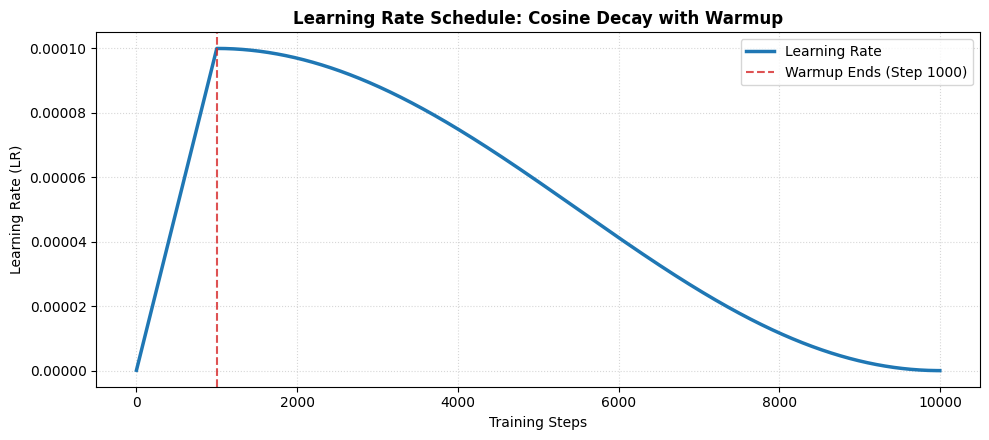

In [40]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

def plot_cosine_schedule():
    """
    CosineSchedule의 동작을 시각적으로 검증하기 위해
    임의의 10,000 스텝(Warmup 10% 가정) 조건 하의 학습률 곡선을 플롯한다.
    """
    # 1. 모의 옵티마이저 생성용 더미 파라미터 정의
    dummy_param = nn.Parameter(torch.zeros(1))
    dummy_optimizer = optim.AdamW([dummy_param], lr=1e-4)
    
    # 2. 스펙 정의 (총 10,000 스텝, Warmup 10%인 1,000 스텝)
    total_steps = 10000
    warmup_steps = 1000
    max_lr = 1e-4
    
    # 3. 스케줄러 인스턴스화
    scheduler = CosineSchedule(dummy_optimizer, total_steps, warmup_steps, max_lr=max_lr)
    
    # 4. 전체 스텝을 돌며 스텝별 학습률 수집
    lr_history = []
    for _ in range(total_steps):
        lr = scheduler.step()
        lr_history.append(lr)
        
    # 5. 시각화 그래프 작성
    plt.figure(figsize=(10, 4.5))
    plt.plot(lr_history, color='#1f77b4', linewidth=2.5, label='Learning Rate')
    
    # 웜업 전환 시점 수직 점선 표기
    plt.axvline(x=warmup_steps, color='#d62728', linestyle='--', alpha=0.8,
                label=f'Warmup Ends (Step {warmup_steps})')
    
    # 그래프 메타 데이터 및 격자 추가
    plt.title('Learning Rate Schedule: Cosine Decay with Warmup', fontsize=12, fontweight='bold')
    plt.xlabel('Training Steps', fontsize=10)
    plt.ylabel('Learning Rate (LR)', fontsize=10)
    plt.grid(True, which='both', linestyle=':', alpha=0.5)
    plt.legend(loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.show()

# 시각화 실행
plot_cosine_schedule()


In [41]:
import time
import pandas as pd
import torch
import torch.nn as nn
from tqdm.auto import tqdm

# ==============================================================================
# 1. 학습 단일 스텝 (train_step) - tqdm 적용 및 최적화
# ==============================================================================
def train_step(model, loader, optimizer, config, device, lr_scheduler=None, epoch_idx=1):
    model.train()
    total_loss = 0
    total_nsp_loss = 0
    total_mlm_loss = 0
    total_nsp_acc = 0
    total_mlm_acc = 0
    
    loss_fn_nsp = nn.CrossEntropyLoss()
    
    # tqdm 진행바 설정 (leave=False로 설정하여 이터레이션 종료 시 화면을 더럽히지 않음)
    progress_bar = tqdm(loader, desc=f"Epoch {epoch_idx:02d} [Train]", leave=False)
    
    for batch in progress_bar:
        enc_tokens, segments, labels_nsp, labels_mlm = batch
        enc_tokens = enc_tokens.to(device)
        segments = segments.to(device)
        labels_nsp = labels_nsp.to(device)
        labels_mlm = labels_mlm.to(device)

        optimizer.zero_grad()
        
        outputs_nsp, outputs_mlm = model(enc_tokens, segments)
        
        # MLM Loss
        loss_mlm = lm_loss(labels_mlm, outputs_mlm)
        total_mlm_loss += loss_mlm.item()
        
        # NSP Loss
        if config.task_recipe == "BERT_Standard":
            loss_nsp = loss_fn_nsp(outputs_nsp, labels_nsp)
            total_nsp_loss += loss_nsp.item()
            loss_total = loss_mlm + loss_nsp
            nsp_acc = (outputs_nsp.argmax(dim=-1) == labels_nsp).float().mean().item()
            total_nsp_acc += nsp_acc
        else:
            loss_total = loss_mlm
            
        total_loss += loss_total.item()
        
        loss_total.backward()
        optimizer.step()
        
        if lr_scheduler is not None:
            lr_scheduler.step()
            
        mlm_acc = lm_acc(labels_mlm, outputs_mlm).item()
        total_mlm_acc += mlm_acc
        
        # 실시간 tqdm 상태창 모니터링 업데이트
        if config.task_recipe == "BERT_Standard":
            progress_bar.set_postfix(Loss=f"{loss_total.item():.4f}", MLM_Acc=f"{mlm_acc:.4f}", NSP_Acc=f"{nsp_acc:.4f}")
        else:
            progress_bar.set_postfix(Loss=f"{loss_total.item():.4f}", MLM_Acc=f"{mlm_acc:.4f}")
        
    n_batches = len(loader)
    return {
        "loss": total_loss / n_batches,
        "nsp_loss": total_nsp_loss / n_batches,
        "mlm_loss": total_mlm_loss / n_batches,
        "nsp_acc": total_nsp_acc / n_batches,
        "mlm_acc": total_mlm_acc / n_batches
    }


# ==============================================================================
# 2. 평가 단일 스텝 (eval_step) - 검증 및 tqdm 적용
# ==============================================================================
def eval_step(model, loader, config, device, epoch_idx=1):
    model.eval()
    total_loss = 0
    total_nsp_loss = 0
    total_mlm_loss = 0
    total_nsp_acc = 0
    total_mlm_acc = 0
    
    loss_fn_nsp = nn.CrossEntropyLoss()
    
    progress_bar = tqdm(loader, desc=f"Epoch {epoch_idx:02d} [Val]", leave=False)
    
    with torch.no_grad():
        for batch in progress_bar:
            enc_tokens, segments, labels_nsp, labels_mlm = batch
            enc_tokens = enc_tokens.to(device)
            segments = segments.to(device)
            labels_nsp = labels_nsp.to(device)
            labels_mlm = labels_mlm.to(device)

            outputs_nsp, outputs_mlm = model(enc_tokens, segments)
            
            # MLM Loss
            loss_mlm = lm_loss(labels_mlm, outputs_mlm)
            total_mlm_loss += loss_mlm.item()
            
            # NSP Loss
            if config.task_recipe == "BERT_Standard":
                loss_nsp = loss_fn_nsp(outputs_nsp, labels_nsp)
                total_nsp_loss += loss_nsp.item()
                loss_total = loss_mlm + loss_nsp
                nsp_acc = (outputs_nsp.argmax(dim=-1) == labels_nsp).float().mean().item()
                total_nsp_acc += nsp_acc
            else:
                loss_total = loss_mlm
                
            total_loss += loss_total.item()
            
            mlm_acc = lm_acc(labels_mlm, outputs_mlm).item()
            total_mlm_acc += mlm_acc
            
            if config.task_recipe == "BERT_Standard":
                progress_bar.set_postfix(Loss=f"{loss_total.item():.4f}", MLM_Acc=f"{mlm_acc:.4f}", NSP_Acc=f"{nsp_acc:.4f}")
            else:
                progress_bar.set_postfix(Loss=f"{loss_total.item():.4f}", MLM_Acc=f"{mlm_acc:.4f}")
                
    n_batches = len(loader)
    return {
        "loss": total_loss / n_batches,
        "nsp_loss": total_nsp_loss / n_batches,
        "mlm_loss": total_mlm_loss / n_batches,
        "nsp_acc": total_nsp_acc / n_batches,
        "mlm_acc": total_mlm_acc / n_batches
    }


# ==============================================================================
# 3. 통합 모델 학습 제어 루틴 (train_model) - 4개/8개 지표 분기 기록 및 저장
# ==============================================================================
def train_model(model, model_name, train_loader, val_loader, config, device, max_epochs=10):
    """
    Train/Val 로더를 병렬 처리하며, 에포크별로 학습 및 검증 지표를 산출하여 기록 및 저장한다.
    """
    seed_everything(42)
    
    max_lr = 1e-4
    optimizer = optim.AdamW(model.parameters(), lr=max_lr, weight_decay=0.01)
    
    total_steps = len(train_loader) * max_epochs
    warmup_steps = int(total_steps * config.learning_rate_warmup)
    lr_scheduler = CosineSchedule(optimizer, total_steps, warmup_steps, max_lr=max_lr)

    # 4대/8대 지표 처리를 위한 태스크 모드 판별
    is_bert = (config.task_recipe == "BERT_Standard")
    
    # 공통 지표 초기화
    history = {
        "epoch": [],
        "train_loss": [], "val_loss": [],
        "train_mlm_loss": [], "val_mlm_loss": [],
        "train_mlm_acc": [], "val_mlm_acc": []
    }
    
    # BERT 특화 NSP 지표 가산 (총 8개 지표화)
    if is_bert:
        history["train_nsp_loss"] = []
        history["val_nsp_loss"] = []
        history["train_nsp_acc"] = []
        history["val_nsp_acc"] = []
        
    history["epoch_time"] = []
    
    print(f"\n>>> Start training {model_name} (Max Epochs: {max_epochs}, Steps: {total_steps}, Warmup: {warmup_steps})")
    
    # 전체 Epoch tqdm 진행 상태바 정의
    epoch_bar = tqdm(range(max_epochs), desc=f"Total Progress [{model_name}]")
    
    for epoch in epoch_bar:
        start_time = time.time()
        
        # 1. Train Step
        metrics_train = train_step(model, train_loader, optimizer, config, device, lr_scheduler, epoch + 1)
        
        # 2. Validation Step (eval_step)
        metrics_val = eval_step(model, val_loader, config, device, epoch + 1)
        
        epoch_time = time.time() - start_time

        # 지표 히스토리 리스트에 추적 추가
        history["epoch"].append(epoch + 1)
        history["train_loss"].append(metrics_train["loss"])
        history["val_loss"].append(metrics_val["loss"])
        history["train_mlm_loss"].append(metrics_train["mlm_loss"])
        history["val_mlm_loss"].append(metrics_val["mlm_loss"])
        history["train_mlm_acc"].append(metrics_train["mlm_acc"])
        history["val_mlm_acc"].append(metrics_val["mlm_acc"])
        
        if is_bert:
            history["train_nsp_loss"].append(metrics_train["nsp_loss"])
            history["val_nsp_loss"].append(metrics_val["nsp_loss"])
            history["train_nsp_acc"].append(metrics_train["nsp_acc"])
            history["val_nsp_acc"].append(metrics_val["nsp_acc"])
            
        history["epoch_time"].append(epoch_time)

        # 에포크 정보 한눈에 출력하기
        if is_bert:
            print(f"Epoch {epoch+1:02d} | "
                  f"Loss(T/V): {metrics_train['loss']:.4f}/{metrics_val['loss']:.4f} | "
                  f"MLM Loss(T/V): {metrics_train['mlm_loss']:.4f}/{metrics_val['mlm_loss']:.4f} | "
                  f"NSP Loss(T/V): {metrics_train['nsp_loss']:.4f}/{metrics_val['nsp_loss']:.4f} | "
                  f"MLM Acc(T/V): {metrics_train['mlm_acc']:.4f}/{metrics_val['mlm_acc']:.4f} | "
                  f"NSP Acc(T/V): {metrics_train['nsp_acc']:.4f}/{metrics_val['nsp_acc']:.4f} | "
                  f"Time: {epoch_time:.1f}s")
        else:
            print(f"Epoch {epoch+1:02d} | "
                  f"Loss(T/V): {metrics_train['loss']:.4f}/{metrics_val['loss']:.4f} | "
                  f"MLM Loss(T/V): {metrics_train['mlm_loss']:.4f}/{metrics_val['mlm_loss']:.4f} | "
                  f"MLM Acc(T/V): {metrics_train['mlm_acc']:.4f}/{metrics_val['mlm_acc']:.4f} | "
                  f"Time: {epoch_time:.1f}s")
                  
        # 상태바 텍스트 업데이트
        epoch_bar.set_postfix(Train_Loss=f"{metrics_train['loss']:.4f}", Val_Loss=f"{metrics_val['loss']:.4f}")
        
    # 에포크 종료 후 가중치 파일 강제 저장
    torch.save(model.state_dict(), f"{model_name}_best.pt")
    
    # 히스토리 데이터프레임 변환 및 CSV 저장
    history_df = pd.DataFrame(history)
    history_df.to_csv(f"{model_name}_history.csv", index=False)
    print(f"[{model_name}] Training Completed. Best weights & history CSV saved successfully.")
    
    return history_df


In [ ]:
# 6대 모델 순차 일괄 자동화 학습 실행 루프
experiments_history = {}

for case_idx, (name, spec) in enumerate(experiments_spec.items()):
    print(f"\n========================================")
    print(f"[{case_idx + 1} / {len(experiments_spec)}] Training: {name}")
    print(f"========================================")
    
    # 1. 설정 결합
    cfg_dict = COMMON_CONFIG.copy()
    cfg_dict.update(spec)
    cfg = Config(cfg_dict)
    
    # 2. 로더 바인딩 (Train / Val 분리 대응)
    if cfg.data_mode == "bert":
        train_loader = bert_train_loader
        val_loader = bert_val_loader
    else:
        train_loader = roberta_train_loader
        val_loader = roberta_val_loader
    
    # 3. 모델 빌드 및 디바이스 이관
    model = build_pretrain_model(cfg)
    model.to(device)
    
    # 4. 학습 실행 (이중 로더 주입 방식으로 변경)
    history_df = train_model(
        model=model, 
        model_name=name, 
        train_loader=train_loader, 
        val_loader=val_loader, 
        config=cfg, 
        device=device, 
        max_epochs=EPOCHS
    )
    experiments_history[name] = history_df
    
    # 5. 자원 정리 및 캐시 비우기 (GPU 메모리 관리)
    del model
    gc.collect()
    torch.cuda.empty_cache()
    time.sleep(2)


## Chapter 6. 정량 평가 (Quantitative Evaluation)

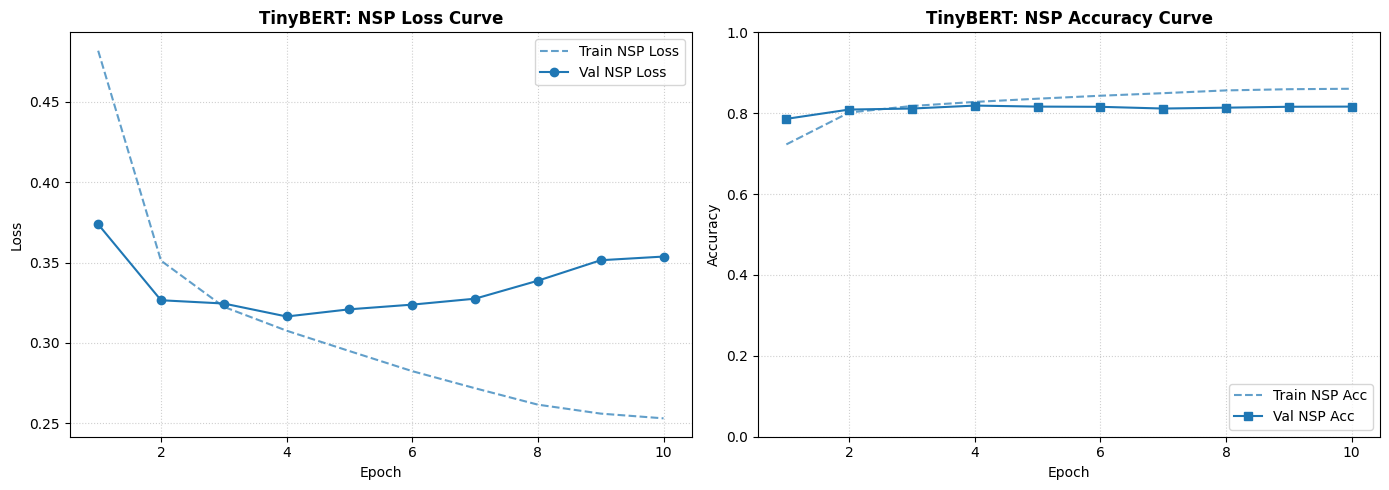

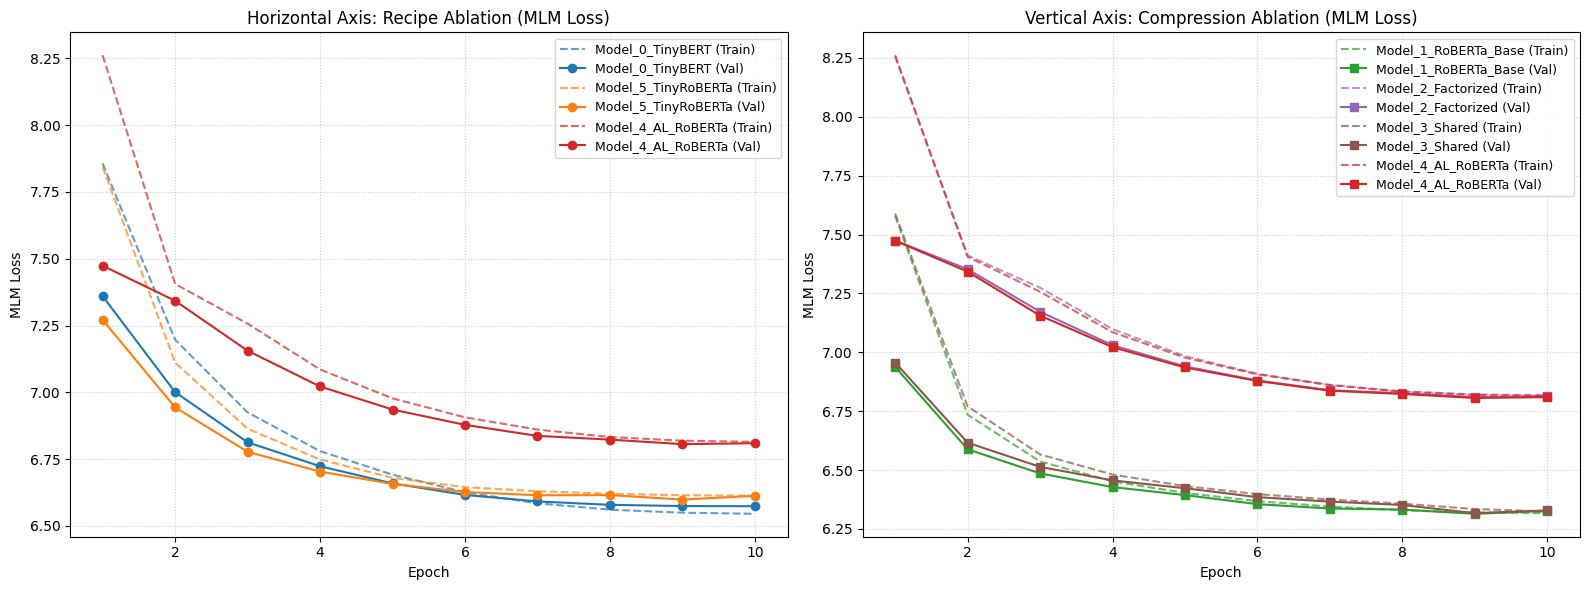

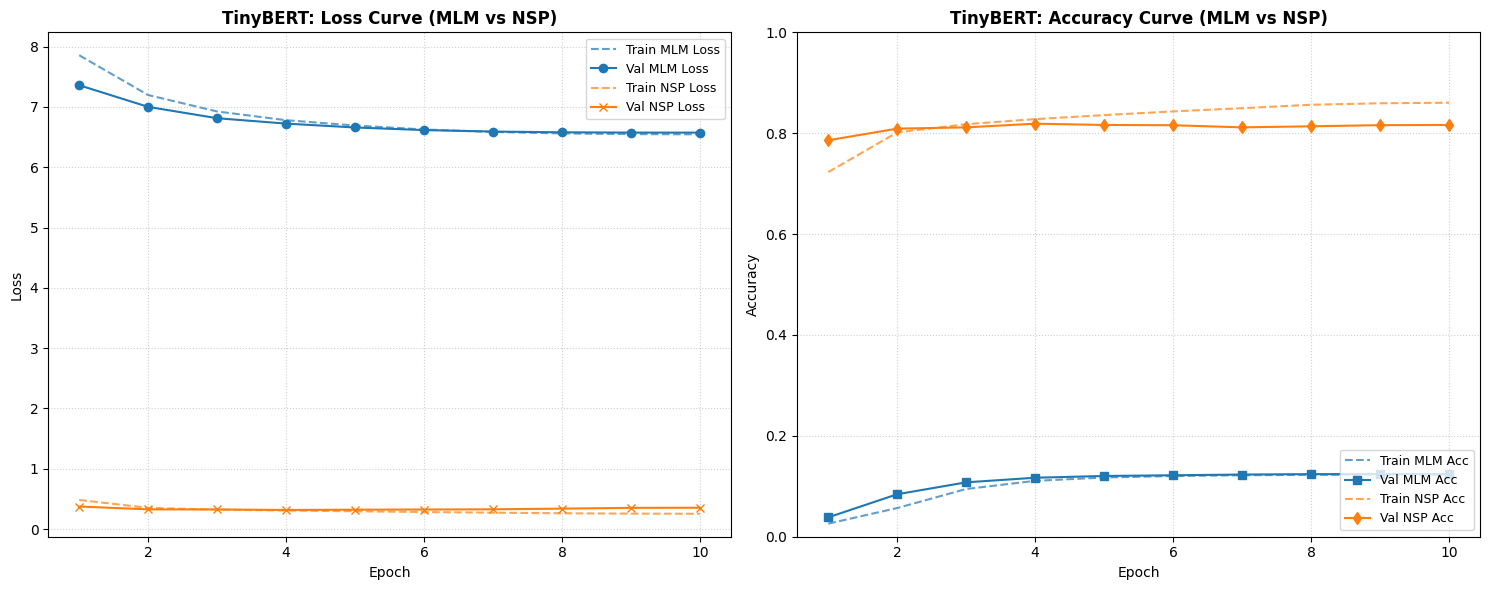

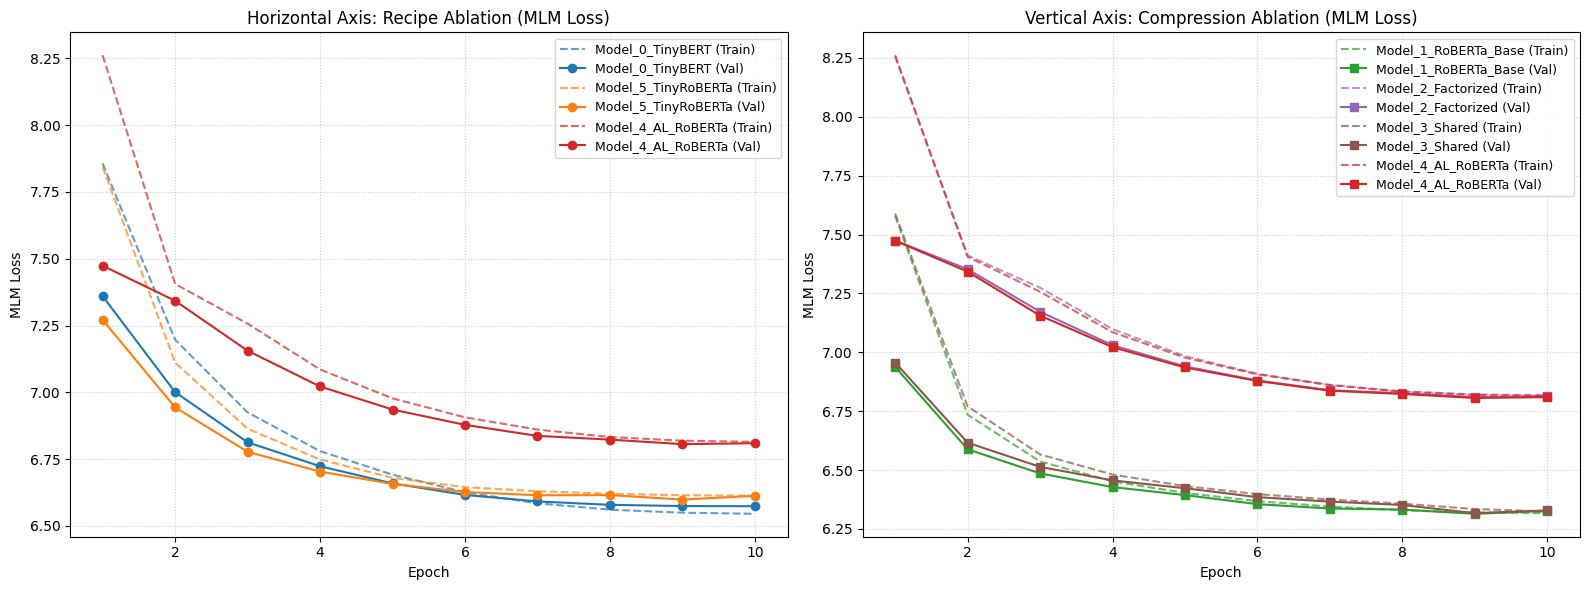

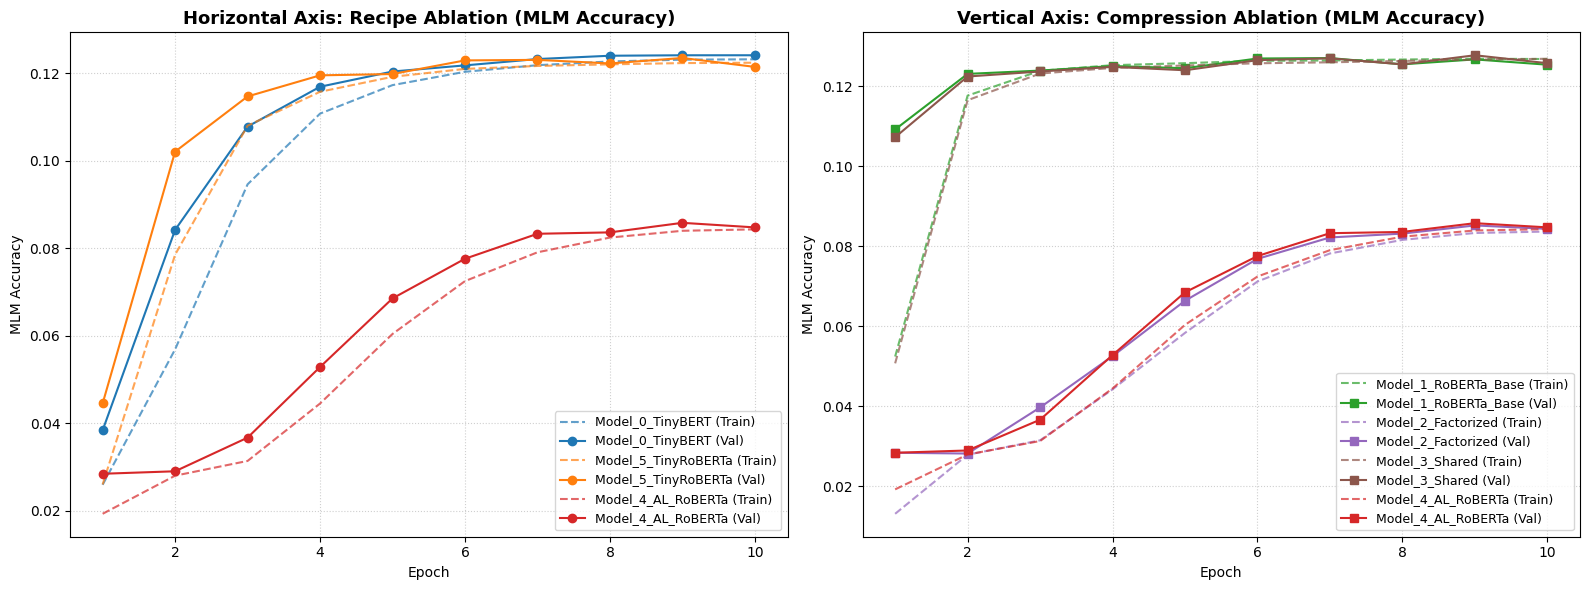

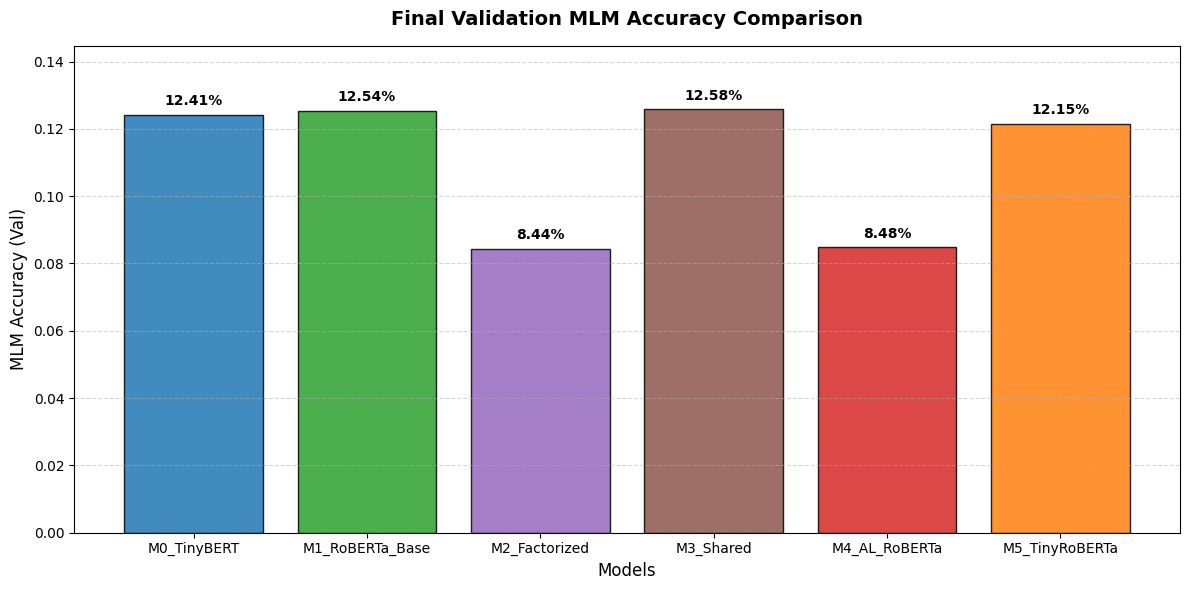

In [58]:
import matplotlib.pyplot as plt
import os
import pandas as pd

# 1. 학습 기록 로드
experiments_spec = {
    "Model_0_TinyBERT": {},
    "Model_1_RoBERTa_Base": {},
    "Model_2_Factorized": {},
    "Model_3_Shared": {},
    "Model_4_AL_RoBERTa": {},
    "Model_5_TinyRoBERTa": {}
}

loaded_histories = {}
for name in experiments_spec.keys():
    csv_path = f"models/{name}_history.csv"
    if os.path.exists(csv_path):
        loaded_histories[name] = pd.read_csv(csv_path)

# ==============================================================================
# [시각화 1] Model_0_TinyBERT 전용 전체 학습 지표 시각화 (1x2 Subplots)
# ==============================================================================
name = "Model_0_TinyBERT"

if name in loaded_histories:
    df = loaded_histories[name]
    epochs = df["epoch"]

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # --- 1. 좌측 그래프: Loss Curves (MLM & NSP) ---
    # MLM Loss (Blue 계열)
    if "train_mlm_loss" in df.columns:
        axes[0].plot(epochs, df["train_mlm_loss"], linestyle="--", color="#1f77b4", alpha=0.7, label="Train MLM Loss")
        axes[0].plot(epochs, df["val_mlm_loss"], linestyle="-", marker="o", color="#1f77b4", label="Val MLM Loss")
    
    # NSP Loss (Orange 계열)
    if "train_nsp_loss" in df.columns:
        axes[0].plot(epochs, df["train_nsp_loss"], linestyle="--", color="#ff7f0e", alpha=0.7, label="Train NSP Loss")
        axes[0].plot(epochs, df["val_nsp_loss"], linestyle="-", marker="x", color="#ff7f0e", label="Val NSP Loss")

    axes[0].set_title("TinyBERT: Loss Curve (MLM vs NSP)", fontsize=12, fontweight="bold")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend(fontsize=9, loc="upper right")
    axes[0].grid(True, linestyle=":", alpha=0.6)

    # --- 2. 우측 그래프: Accuracy Curves (MLM & NSP) ---
    # MLM Acc (Blue 계열)
    if "train_mlm_acc" in df.columns:
        axes[1].plot(epochs, df["train_mlm_acc"], linestyle="--", color="#1f77b4", alpha=0.7, label="Train MLM Acc")
        axes[1].plot(epochs, df["val_mlm_acc"], linestyle="-", marker="s", color="#1f77b4", label="Val MLM Acc")
    
    # NSP Acc (Orange 계열)
    if "train_nsp_acc" in df.columns:
        axes[1].plot(epochs, df["train_nsp_acc"], linestyle="--", color="#ff7f0e", alpha=0.7, label="Train NSP Acc")
        axes[1].plot(epochs, df["val_nsp_acc"], linestyle="-", marker="d", color="#ff7f0e", label="Val NSP Acc")

    axes[1].set_title("TinyBERT: Accuracy Curve (MLM vs NSP)", fontsize=12, fontweight="bold")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0.0, 1.0)  # 세로축 범위 0.0 ~ 1.0 고정
    axes[1].legend(fontsize=9, loc="lower right")
    axes[1].grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()
else:
    print(f"[{name}]의 데이터가 존재하지 않거나 로드되지 않았습니다. CSV 파일을 확인해주세요.")



# ==============================================================================
# [시각화 2] 학습 결과 러닝 커브 통합 시각화 (점선: Train, 실선: Val)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- [좌측 그래프] Horizontal Axis: Recipe Ablation ---
axes[0].set_title("Horizontal Axis: Recipe Ablation (MLM Loss)")
horizontal_models = ["Model_0_TinyBERT", "Model_5_TinyRoBERTa", "Model_4_AL_RoBERTa"]

for name in horizontal_models:
    if name in loaded_histories:
        color = model_colors[name]
        epochs = loaded_histories[name]["epoch"]
        
        # Train Loss (점선)
        axes[0].plot(epochs, loaded_histories[name]["train_mlm_loss"], 
                     linestyle="--", color=color, alpha=0.7, label=f"{name} (Train)")
        # Val Loss (실선)
        axes[0].plot(epochs, loaded_histories[name]["val_mlm_loss"], 
                     linestyle="-", marker="o", color=color, label=f"{name} (Val)")

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MLM Loss")
axes[0].legend(fontsize=9, loc="upper right")
axes[0].grid(True, linestyle=":", alpha=0.6)

# --- [우측 그래프] Vertical Axis: Compression Ablation ---
axes[1].set_title("Vertical Axis: Compression Ablation (MLM Loss)")
vertical_models = ["Model_1_RoBERTa_Base", "Model_2_Factorized", "Model_3_Shared", "Model_4_AL_RoBERTa"]

for name in vertical_models:
    if name in loaded_histories:
        color = model_colors[name]
        epochs = loaded_histories[name]["epoch"]
        
        # Train Loss (점선)
        axes[1].plot(epochs, loaded_histories[name]["train_mlm_loss"], 
                     linestyle="--", color=color, alpha=0.7, label=f"{name} (Train)")
        # Val Loss (실선)
        axes[1].plot(epochs, loaded_histories[name]["val_mlm_loss"], 
                     linestyle="-", marker="s", color=color, label=f"{name} (Val)")

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MLM Loss")
axes[1].legend(fontsize=9, loc="upper right")
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()


# ==============================================================================
# 1. 에포크별 MLM Accuracy 학습 곡선 시각화 (점선: Train, 실선: Val)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- [좌측 그래프] Horizontal Axis: Recipe Ablation (Accuracy) ---
axes[0].set_title("Horizontal Axis: Recipe Ablation (MLM Accuracy)", fontsize=13, fontweight='bold')
horizontal_models = ["Model_0_TinyBERT", "Model_5_TinyRoBERTa", "Model_4_AL_RoBERTa"]

for name in horizontal_models:
    if name in loaded_histories:
        color = model_colors[name]
        epochs = loaded_histories[name]["epoch"]
        
        # Train Acc (점선)
        axes[0].plot(epochs, loaded_histories[name]["train_mlm_acc"], 
                     linestyle="--", color=color, alpha=0.7, label=f"{name} (Train)")
        # Val Acc (실선)
        axes[0].plot(epochs, loaded_histories[name]["val_mlm_acc"], 
                     linestyle="-", marker="o", color=color, label=f"{name} (Val)")

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MLM Accuracy")
axes[0].legend(fontsize=9, loc="lower right")
axes[0].grid(True, linestyle=":", alpha=0.6)

# --- [우측 그래프] Vertical Axis: Compression Ablation (Accuracy) ---
axes[1].set_title("Vertical Axis: Compression Ablation (MLM Accuracy)", fontsize=13, fontweight='bold')
vertical_models = ["Model_1_RoBERTa_Base", "Model_2_Factorized", "Model_3_Shared", "Model_4_AL_RoBERTa"]

for name in vertical_models:
    if name in loaded_histories:
        color = model_colors[name]
        epochs = loaded_histories[name]["epoch"]
        
        # Train Acc (점선)
        axes[1].plot(epochs, loaded_histories[name]["train_mlm_acc"], 
                     linestyle="--", color=color, alpha=0.7, label=f"{name} (Train)")
        # Val Acc (실선)
        axes[1].plot(epochs, loaded_histories[name]["val_mlm_acc"], 
                     linestyle="-", marker="s", color=color, label=f"{name} (Val)")

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MLM Accuracy")
axes[1].legend(fontsize=9, loc="lower right")
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# ==============================================================================
# 2. 최종 Validation MLM Accuracy 비교 차트 (막대 그래프)
# ==============================================================================
names = []
accuracies = []
bar_colors = []

for name in experiments_spec.keys():
    if name in loaded_histories:
        short_name = name.replace("Model_", "M")
        names.append(short_name)
        accuracies.append(loaded_histories[name]["val_mlm_acc"].iloc[-1])
        bar_colors.append(model_colors[name])

plt.figure(figsize=(12, 6))
bars = plt.bar(names, accuracies, color=bar_colors, edgecolor='black', alpha=0.85)

plt.title("Final Validation MLM Accuracy Comparison", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("MLM Accuracy (Val)", fontsize=12)
plt.xlabel("Models", fontsize=12)

# 각 막대 위에 백분율 수치 텍스트 표시
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.002, 
             f"{yval * 100:.2f}%", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, max(accuracies) * 1.15)
plt.tight_layout()
plt.show()


# [실험 결과 분석 및 결론]

### 1. NSP(Next Sentence Prediction) 태스크 분석 (시각화 1)
* **현상:** NSP 태스크는 MLM 태스크 대비 손실(Loss)과 정확도(Accuracy) 모두 월등히 높은 수치를 기록함.
* **해석:** NSP는 모델에 있어 매우 용이한 작업이었으며, 오히려 MLM 학습을 방해할 여지가 있음. 이는 RoBERTa 등 현대 인코더 모델에서 NSP 태스크가 제외된 이유를 설명함.

### 2. 레시피 및 압축 아블레이션 분석 (시각화 2 & 3)
* **임베딩 분해(Factorized Embedding):** 임베딩 분해를 적용한 모델들의 성능이 유의미하게 저조하였음.
* **BERT와 RoBERTa 비교:** 일반 BERT가 약 5에포크 시점에 RoBERTa를 역전하여 최종 성능 우위를 보임.
  * **원인:** 동적 마스킹(RoBERTa)의 학습 난이도가 높았던 반면, BERT는 매 에포크 동일한 마스크 패턴을 반복 학습하여 손실이 더 크게 감소한 것으로 판단됨.
  * **한계:** BERT와 RoBERTa 간의 구조적 아블레이션 제어가 완벽하지 않아 정확한 원인을 단정하기는 어려움.

### 3. 압축 기법 비교 분석 (Model 1 vs Model 3)
* **가중치 공유(Weight Sharing):** Model 3(Shared)은 Model 1(RoBERTa Base) 대비 파라미터 수가 약 3M개 적음에도 성능 차이가 거의 없음. 소규모 모델 설계에서도 가중치 공유가 효과적임을 증명함.
* **임베딩 분해:** 파라미터 제약조건을 맞추기 위해 임베딩 차원을 32로 설정한 것이 성능 하락의 원인임. 8,000 크기의 단어 사전(Vocab Size)에서 32차원의 공간은 모든 토큰을 고유한 위치에 배치할 수는 있으나 토큰 간 미세한 의미 구분을 불가능하게 만듦.

### 4. 최종 결론 및 후속 실험 제안
* **최적 모델:** 1M 파라미터 수준에서 가장 우수한 성능을 보인 모델은 베이스라인인 TinyBERT임.
* **ALBERT 구조 평가:** ALBERT 핵심 구조 중 가중치 공유는 파라미터 수 대비 성능 보존율이 높았으나, 임베딩 분해는 성능 하락의 주원인으로 작용함.
* **향후 계획:** 임베딩 분리는 단점이 존재하나, 은닉 차원(Hidden Dimension)을 그대로 유지한 채 임베딩 차원만 64로 확장하는 추가 실험을 고려할 필요가 있음.


## Chapter 7. 정성 평가 (Qualitative Evaluation)

In [48]:
def predict_masked_tokens(model, vocab, sentence, config, device, top_k=5):
    model.eval()
    tokens_org = ["[CLS]"] + vocab.encode_as_pieces(sentence) + ["[SEP]"]
    
    # [MASK] 임의 주입 위치 검증
    mask_indices = [i for i, t in enumerate(tokens_org) if "[MASK]" in t or t == "[MASK]"]
    if len(mask_indices) == 0:
        print("No [MASK] token found in sentence. Forcing middle mask.")
        mid = len(tokens_org) // 2
        tokens_org[mid] = "[MASK]"
        mask_indices = [mid]

    enc_tokens = [vocab.piece_to_id(t) for t in tokens_org]
    enc_tokens += [0] * (config.max_position_embeddings - len(enc_tokens))
    segments = [0] * config.max_position_embeddings

    x_tokens = torch.tensor([enc_tokens], dtype=torch.long).to(device)
    x_segs = torch.tensor([segments], dtype=torch.long).to(device)

    with torch.no_grad():
        _, outputs_mlm = model(x_tokens, x_segs)
        outputs_mlm = F.softmax(outputs_mlm, dim=-1)  # ← 이 한 줄 추가
        
    results = {}
    for m_idx in mask_indices:
        pred_dist = outputs_mlm[0, m_idx]
        top_vals, top_ids = torch.topk(pred_dist, top_k)
        top_pieces = [vocab.id_to_piece(tid.item()) for tid in top_ids]
        results[m_idx] = list(zip(top_pieces, top_vals.tolist()))
        
    return tokens_org, results

In [51]:
test_sentences = [
    # 1. 지리/사회 정보 (고빈도 템플릿 - 난이도: 하)
    "대한민국의 수도는 [MASK]이다.", 
    # 정답 후보: 서울 (위키백과 내 대한민국-수도-서울의 동시 출현 빈도가 극도로 높음)
    
    # 2. 인물/역사 정보 (백과사전 서술형 문체 - 난이도: 중)
    "이순신은 조선 시대의 [MASK]이었다.", 
    # 정답 후보: 장군, 무신, 군인 (인물 문서의 표준 요약 템플릿 구조)
    
    # 3. 기초 과학 사실 (정형화된 지식 서술 - 난이도: 상)
    "지구는 태양계의 세 번째 [MASK]이다."
    # 정답 후보: 행성, 천체, 위성 (천문 과학 카테고리의 대표적 정의 문장)
]

for name, spec in experiments_spec.items():
    print(f"\n========================================")
    print(f"Qualitative Prediction: {name}")
    print(f"========================================")
    
    cfg_dict = COMMON_CONFIG.copy()
    cfg_dict.update(spec)
    cfg = Config(cfg_dict)
    
    model = build_pretrain_model(cfg)
    weight_path = f"models/{name}_best.pt"
    if os.path.exists(weight_path):
        model.load_state_dict(torch.load(weight_path, map_location=device))
        model.to(device)
        
        for sentence in test_sentences:
            toks, preds = predict_masked_tokens(model, vocab, sentence, cfg, device)
            print(f"Input: {' '.join(toks)}")
            for m_idx, pred in preds.items():
                print(f"  [MASK] position {m_idx} Top-5 Predictions:")
                for piece, prob in pred:
                    print(f"    - {piece:<10}: {prob:.4f}")
    else:
        print(f"Weight file {weight_path} not found. Skipping.")
        
    del model
    torch.cuda.empty_cache()


Qualitative Prediction: Model_0_TinyBERT
Input: [CLS] ▁대한민국의 ▁수도 는 ▁ [MASK] 이다 . [SEP]
  [MASK] position 5 Top-5 Predictions:
    - ▁다음       : 0.0663
    - ▁역        : 0.0600
    - ▁대한민국의    : 0.0579
    - ▁다음을      : 0.0412
    - ▁지역에      : 0.0346
Input: [CLS] ▁이 순 신 은 ▁조선 ▁시대의 ▁ [MASK] 이었다 . [SEP]
  [MASK] position 8 Top-5 Predictions:
    - ▁다음       : 0.1565
    - ▁있는       : 0.0596
    - ▁지역에      : 0.0273
    - ▁역        : 0.0271
    - ▁위치한      : 0.0246
Input: [CLS] ▁지구 는 ▁태양 계의 ▁세 ▁번째 ▁ [MASK] 이다 . [SEP]
  [MASK] position 8 Top-5 Predictions:
    - ▁다음을      : 0.2466
    - ▁다음       : 0.1590
    - ▁가리키는     : 0.0624
    - ▁다음과      : 0.0436
    - ▁다른       : 0.0346

Qualitative Prediction: Model_5_TinyRoBERTa
Input: [CLS] ▁대한민국의 ▁수도 는 ▁ [MASK] 이다 . [SEP]
  [MASK] position 5 Top-5 Predictions:
    - ▁         : 0.0646
    - .         : 0.0302
    - 의         : 0.0170
    - ,         : 0.0121
    - )         : 0.0106
Input: [CLS] ▁이 순 신 은 ▁조선 ▁시대의 ▁ [MASK] 이었다 . [SEP]
  [MASK]

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_16344\3319402631.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weight_path, m

Input: [CLS] ▁대한민국의 ▁수도 는 ▁ [MASK] 이다 . [SEP]
  [MASK] position 5 Top-5 Predictions:
    - .         : 0.0338
    - ▁         : 0.0267
    - 이다        : 0.0199
    - 는         : 0.0177
    - 은         : 0.0145
Input: [CLS] ▁이 순 신 은 ▁조선 ▁시대의 ▁ [MASK] 이었다 . [SEP]
  [MASK] position 8 Top-5 Predictions:
    - 의         : 0.0214
    - .         : 0.0180
    - 은         : 0.0171
    - 을         : 0.0160
    - ▁이        : 0.0147
Input: [CLS] ▁지구 는 ▁태양 계의 ▁세 ▁번째 ▁ [MASK] 이다 . [SEP]
  [MASK] position 8 Top-5 Predictions:
    - ▁         : 0.0284
    - .         : 0.0283
    - ,         : 0.0184
    - ▁있다       : 0.0175
    - 이다        : 0.0152

Qualitative Prediction: Model_3_Shared
Input: [CLS] ▁대한민국의 ▁수도 는 ▁ [MASK] 이다 . [SEP]
  [MASK] position 5 Top-5 Predictions:
    - 이다        : 0.0362
    - .         : 0.0214
    - 는         : 0.0197
    - 은         : 0.0169
    - ▁대한민국의    : 0.0125
Input: [CLS] ▁이 순 신 은 ▁조선 ▁시대의 ▁ [MASK] 이었다 . [SEP]
  [MASK] position 8 Top-5 Predictions:
    - ▁조선       

# [정성적 평가 결과 분석 (Qualitative Evaluation)]

### 1. 예측 확률 분포 분석
* 모든 모델에서 마스킹된 토큰에 대해 10% 이상의 예측 확신도를 가진 경우가 거의 존재하지 않음.
* Top-5 후보 단어들의 예측 확률이 뚜렷한 변별력 없이 모두 균등하게 낮은 수치로 분포함.

### 2. 예측 단어 일관성 및 문맥 왜곡 현상
* 서로 다른 맥락의 입력 문장임에도 불구하고 문장 부호, 조사 등 문맥과 직접적 관련이 없는 동일한 토큰들이 상위 예측 결과에 중복 노출됨.
* 문맥을 통한 의미론적 추론 대신, 입력 문장 내에 이미 존재하는 특정 단어(예: 태양, 지구, 조선 등)를 그대로 복사하여 예측 값으로 출력하는 경향을 보임.

### 3. 종합 결론
* 정성적 예측 결과는 전형적인 학습 부족(Underfitting) 상태를 나타냄.
* 데이터셋 크기를 축소하여 학습했음에도 불구하고, 모델이 문맥을 온전히 이해하기에는 절대적인 학습 에포크 및 스텝 수가 부족했음이 드러남.
* 정상적인 추론 성능 확보를 위해서는 대규모 코퍼스의 추가 확보와 충분한 양의 학습 스텝 수행이 동반되어야 함.


## Chapter 8. 프로젝트 총평 및 회고

* 이전 노드 피드백을 반영해 결과 분석 파트에 있어서는 오직 제가 관찰한 부분만 ai에게 정리시켜서 깔끔하게 정리해 보았습니다. 시간이 부족해서 자세한 분석을 못했고, 전체적인 분량이 짧아졌지만, 마크다운셀의 결과 분석 내용이 제가 이해했던 내용이고, 다시봐도 무슨 말인지 알 수 있게 정리 된것 같습니다. 이전에는 제가 해석한 내용 + ai가 재해석 및 부풀린 내용을 담고, 그걸 보고 공부하는 식이었는데, 앞으로는 ai가 부풀리거나 재해석 하기 전에 제가 좀더 많은 유의미한 정보를 캐치하는 연습을 해야될거 같다고 생각했습니다.

* 데이터셋의 한계와 학습시간(총 스텝 수) 부족으로 잘 훈현되고 성능이 좋은 모델이 나오지 않는것이 아쉽지만 이번 모듈에서 2일에 한번씩 서로 다른 모델에 대해 아블레이션 스터디를 진행하면서, 아블레이션 실험설계와 실험 단계(토큰화 -> 데이터 전처리 -> 모델설계 ->학습 설계 및 학습 -> 정량 및 정성 분석)에 대해 조금씩 익숙해진것 같습니다.

* 이번 프로젝트에선 al-RoBERTa 모델에서 임베딩 분리가 성능이 좋지 않았는데, 이 베이스 모델을 선정할때 임베딩 차원의 경우의 수가 32와 64가 있었고, 또 다른쪽에도 조금씩 수정해볼만한 하이퍼 파라미터가 있었는데, 다음에는 아블레이션을 하기전에 고정하는 통제변수(하이퍼파라미터 등)을 정하는데 좀 더 신중해야 할것 같고, 또 시간이 충분하다면 1~2에폭정도로 짧게 돌려보면서 최적의 조건을 찾는 방법도 시도해 봐야겠다고 생각했습니다.